## Configure

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from os.path import join
from pathlib import Path
import yaml
from yaml.loader import SafeLoader
import pandas as pd
import geopandas as gpd
import numpy as np
import rioxarray as rio
from scipy import stats
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import matplotlib.ticker as mtick
import matplotlib.colors as colors
from matplotlib.colorbar import ColorbarBase
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import contextily as cx

In [3]:
# Name the fips, statefips, stateabbr, and nation that
# we are using for this analysis
fips_args = {
    'FIPS': ['42101'], 
    'STATEFIPS': ['42'],
    'STATEABBR': ['PA'],
    'NATION': ['US']
}
FIPS = fips_args['FIPS'][0]
NATION = fips_args['NATION'][0]

ABS_DIR = Path().absolute().parents[0]

CONFIG_FILEP = join(ABS_DIR, 'config', 'config.yaml')
# Open the config file and load
with open(CONFIG_FILEP) as f:
    CONFIG = yaml.load(f, Loader=SafeLoader)

# Wildcards for urls
URL_WILDCARDS = CONFIG['url_wildcards']

# Get the file extensions for api endpoints
API_EXT = CONFIG['api_ext']

# Get the CRS constants
NSI_CRS = CONFIG['nsi_crs']

# Dictionary of ref_names
REF_NAMES_DICT = CONFIG['ref_names']

# Dictionary of ref_id_names
REF_ID_NAMES_DICT = CONFIG['ref_id_names']

# Coefficient of variation
# for structure values
COEF_VARIATION = CONFIG['coef_var']

# First floor elevation dictionary
FFE_DICT = CONFIG['ffe_dict']

# Number of states of the world
N_SOW = CONFIG['sows']

# Data for flood depth grids
# Get hazard model variables
HAZ_FILEN = CONFIG['haz_filename']
# Get CRS for depth grids
HAZ_CRS = CONFIG['haz_crs']
# Ensemble members
HAZ_NENS = CONFIG['haz_nens']
# Number of columns for each depth grid
HAZ_NCOLS = CONFIG['haz_ncols']
# Num rows for each depth grid
HAZ_NROWS = CONFIG['haz_nrows']
# Lower left x coordinate
HAZ_XLL = CONFIG['haz_xll']
# Lower left y coordinate
HAZ_YLL = CONFIG['haz_yll']
# Cell resolution
HAZ_RES = CONFIG['haz_res']
# NODATA values
HAZ_NODATA = CONFIG['haz_nodata']

# Get the files we need downloaded
DOWNLOAD = pd.json_normalize(CONFIG['download'], sep='_').T

# We can also specify the filepath to the
# raw data directory
FR = join(ABS_DIR, "data", "raw")

# And external - where our hazard data should be
FE = join(FR, "external")

# Set up interim and results directories as well
# We already use "FR" for raw, we use "FO" 
# because you can also think of results
# as output
FI = join(ABS_DIR, "data", "interim")
FO = join(ABS_DIR, "data", "results")

# For figures
FIG_DIR = join(ABS_DIR, "fig")

# "Raw" data directories for exposure, vulnerability (vuln) and
# administrative reference files
EXP_DIR_R = join(FR, "exp")
VULN_DIR_R = join(FR, "vuln")
REF_DIR_R = join(FR, "ref")
# Haz is for depth grids
HAZ_DIR_R = join(FE, "haz")
# Pol is for NFHL
POL_DIR_R = join(FR, "pol")

# Unzip directory 
UNZIP_DIR = join(FR, "unzipped")

# We want to process unzipped data and move it
# to the interim directory where we keep
# processed data
# Get the filepaths for unzipped data
# We unzipped the depth grids (haz) and 
# ddfs (vuln) into the "external"/ subdirectory
HAZ_DIR_UZ = join(UNZIP_DIR, "external", "haz")
POL_DIR_UZ = join(UNZIP_DIR, "pol")
REF_DIR_UZ = join(UNZIP_DIR, "ref")
VULN_DIR_UZ = join(UNZIP_DIR, "external", "vuln")

# Our study domain
CLIP_SHP_FILEP = join(HAZ_DIR_UZ, 'RIFT_domain', 'domain_1.shp')

# "Interim" data directories
EXP_DIR_I = join(FI, "exp")
VULN_DIR_I = join(FI, "vuln")
REF_DIR_I = join(FI, "ref")
# Haz is for depth grids
HAZ_DIR_I = join(FI, "haz")
# Pol is for NFHL
POL_DIR_I = join(FI, "pol")

## Load data for analysis and plotting

In [25]:
# Helpful to store the dataframes as a dictionary where the 
# experiment name is the key
# The naming conventions are different for considering uncertainty
# and this code accounts for that
output_dir = join(FO, 'ensembles')
dg_id = "009"
exps = ['phil', 'nsi_ddfs', 'nsi_unsafe',
        'nsi_phil', 'phil_unsafe', 'nsi_allphil']

all_results = {}
for exp_name in exps:
    main_exp_name = f"main_exp_{dg_id}_{exp_name}_main.pqt"
    ens_result = pd.read_parquet(join(output_dir, main_exp_name))
    all_results[exp_name] = ens_result

nounc_name = f"no_unc_{dg_id}_main.pqt"
all_results["no_unc"] = pd.read_parquet(join(output_dir, nounc_name))

In [18]:
all_results['no_unc'].sum()/1e6

naccs_loss_009    427.212936
dtype: float64

In [26]:
all_results['no_unc'].sum()/1e6

naccs_loss_009    427.212936
dtype: float64

In [22]:
len(all_results['no_unc'])

20481

In [19]:
all_results['phil'].groupby('bfid')['naccs_loss_009'].mean().sum()/1e6

np.float64(371.3474597253851)

In [20]:
all_results['phil']['bfid'].value_counts()

bfid
15202    1000
68781    1000
39990    1000
31255    1000
47873    1000
         ... 
16355    1000
81969    1000
46066    1000
38455    1000
39831    1000
Name: count, Length: 19244, dtype: int64

In [18]:
# Spatial data
clip_geo = gpd.read_file(CLIP_SHP_FILEP)
tract_ref = gpd.read_file(join(REF_DIR_I, FIPS, 'tract.gpkg'))[['GEOID', 'geometry']]

# Inventories
# Spatial
nsi_clip_out = gpd.read_file(join(EXP_DIR_I, FIPS, 'nsi_res.gpkg'))
phil_inv_out = gpd.read_file(join(EXP_DIR_I, FIPS, 'phil_res.gpkg'))
# Ensembles
phil_inv_ens = pd.read_parquet(join(EXP_DIR_I, FIPS, 'phil_inv_ens.pqt'))
nsi_inv_ens = pd.read_parquet(join(EXP_DIR_I, FIPS, 'nsi_inv_ens.pqt'))

# Data to link inventories to tracts
phil_refs = pd.read_parquet(join(EXP_DIR_I, FIPS, 'phil_ref.pqt'))
nsi_refs = pd.read_parquet(join(EXP_DIR_I, FIPS, 'nsi_ref.pqt'))

# Depths across inundation model ensembles
nsi_depths_df = pd.read_parquet(join(EXP_DIR_I, FIPS, 'nsi_depths_updated.pqt'))#.set_index('fd_id')
phil_depths_df = pd.read_parquet(join(EXP_DIR_I, FIPS, 'phil_depths.pqt')).set_index('bfid')

## Postprocessing results for figures

There are a few datasets that will be helpful for analyzing and visualizing the results. 

First, we want to identify consistent records between the structure inventories and categorize records in terms of their match types across inventories. This is the basis for most of our main results. For each match type, we want to know about damage discrepancies, rank discrepancies, etc., so there is a lot of processing here. 

Second, we want to have results across all experiments summarized at the census tract level. A main inquiry of research is whether damage discrepancies at the property level cancel out at the scales most typical for using prospective damage estimates in support of decisions. 

Finally, we want to calculate how well the various experiments compare to the "best" representation of damages using the Philly inventory. 

In [19]:
# Can only choose depth grids that we generated ensembles for
dg_id = '009'
dam_col = 'naccs_loss_' + dg_id

### Get match types

We calculate match types across inventories. There are a few high level categories. First, we have NSI records & Philly records that uniquely link to each other over space. There are different levels of characteristic matchin gin there. Second, we have  NSI records without a link to a Philly record over space. Third, there is the same as #2 except reversed. Finally, there are cases where several NSI records link to the same Philly record over space (many-to-one), which is problematic. We could arbitrarily take one of the links as a one-to-one and leave the rest as NSI only, but that is a different logic than the "true" NSI only cases. The "right" way to process these is probably to aggregate them (apartment buildings or condos most likely) but the issue is that when you only have the NSI data you don't know how to aggregate things like stories because do we know if the records are vertically stacked or side by side (and what if foundation type is different?). For loss-estimation purposes, we use what info we have for the DDFs. So, for post-proccessing, we do want to aggregate the NSI records that share a bfid link at least in terms of their loss difference. So, I think we should treat it as its own match type. The Philly properties will be there as well (because we're seeing how the losses net)

In [20]:
# Reference of nsi records linked to philly footprints
lnk_nsi_loc = gpd.sjoin(nsi_clip_out,
                        phil_inv_out,
                        predicate='within',
                        how='inner')

# Use the spatial links to add bfid to the nsi data
fd_bfid_lnk = dict(zip(lnk_nsi_loc['fd_id'], lnk_nsi_loc['bfid']))
nsi_match = nsi_inv_ens.reset_index()
nsi_match['bfid'] = nsi_match['fd_id'].map(fd_bfid_lnk)
# We will link up all the records across inventories
# including those w/o a match in the other in order to define
# different match categories

nsi_match.loc[nsi_match['bfid'].isnull(), 'bfid'] = nsi_match.loc[nsi_match['bfid'].isnull()]['fd_id']

match_df = nsi_match.merge(phil_inv_ens.reset_index(),
                           on='bfid',
                           suffixes=['_nsi', '_phil'],
                           how='outer')

# matches = match_df.groupby(['bfid', 'num_story_phil', 'found_type_phil',
#                             'occtype_phil', 'occtype_nsi',
#                             'num_story_nsi', 'found_type_nsi']).size().rename('n').reset_index()

matches = match_df.groupby(['bfid', 'num_story_phil', 'found_type_phil',
                            'num_story_nsi', 'found_type_nsi']).size().rename('n').reset_index()

matches['story_match'] = 0
matches.loc[matches['num_story_phil'] == matches['num_story_nsi'],
            'story_match'] = 1

matches['found_type_match'] = 0
matches.loc[matches['found_type_phil'] == matches['found_type_nsi'],
            'found_type_match'] = 1

# matches['occ_match'] = 0
# matches.loc[matches['occtype_phil'] == matches['occtype_nsi'],
#             'occ_match'] = 1

# matches.loc[(matches['story_match'] == 0) &
#             (matches['found_type_match'] == 0) &
#             (matches['occ_match'] == 0),
#             'Matches'] = 'Location Only'

# matches.loc[((matches['story_match'] == 1) &
#              (matches['found_type_match'] == 1) &
#              (matches['occ_match'] == 1)),
#             'Matches'] = 'All'

# matches.loc[((matches['story_match'] == 1) &
#              (matches['found_type_match'] == 1) &
#              (matches['occ_match'] == 0)),
#             'Structure Matches'] = 'Basement & Stories'

# matches.loc[((matches['story_match'] == 1) &
#              (matches['found_type_match'] == 0) &
#              (matches['occ_match'] == 0)),
#             'Structure Matches'] = 'Stories'

# matches.loc[((matches['story_match'] == 0) &
#              (matches['found_type_match'] == 1) &
#              (matches['occ_match'] == 0)),
#             'Structure Matches'] = 'Basement'

# matches.loc[((matches['story_match'] == 0) &
#              (matches['found_type_match'] == 0) &
#              (matches['occ_match'] == 1)),
#             'Structure Matches'] = 'Occupancy'

# matches.loc[((matches['story_match'] == 1) &
#              (matches['found_type_match'] == 0) &
#              (matches['occ_match'] == 1)),
#             'Structure Matches'] = 'Stories & Occupancy'

# matches.loc[((matches['story_match'] == 0) &
#              (matches['found_type_match'] == 1) &
#              (matches['occ_match'] == 1)),
#             'Structure Matches'] = 'Basement & Occupancy'

matches.loc[(matches['story_match'] == 0) &
            (matches['found_type_match'] == 0),
            'Matches'] = 'Location Only'

matches.loc[((matches['story_match'] == 1) &
             (matches['found_type_match'] == 1)),
            'Matches'] = 'All'

matches.loc[((matches['story_match'] == 1) &
             (matches['found_type_match'] == 0)),
            'Matches'] = 'Stories'

matches.loc[((matches['story_match'] == 0) &
             (matches['found_type_match'] == 1)),
            'Matches'] = 'Basement'

# match_agg_l = ['Stories', 'Basement', 'Occupancy', 'Stories & Occupancy',
#                'Basement & Stories', 'Basement & Occupancy']
# matches.loc[matches['Structure Matches'].isin(match_agg_l),
#             'Matches'] = 'Location & Subset'

# If more than one NSI linked to same bfid, update match type
many_nsi = match_df.groupby(['bfid']).size().rename('n').reset_index()
many_nsi_ids = many_nsi[many_nsi['n'] > 1]['bfid']
matches.loc[matches['bfid'].isin(many_nsi_ids),
            'Matches'] = 'Many NSI In One Philly'

match_dict = dict(zip(matches['bfid'].astype(int), matches['Matches']))
# specific_match_dict = dict(zip(matches['bfid'].astype(int), matches['Structure Matches']))

phil_only = match_df[(~match_df['bfid'].isin(matches['bfid'])) & (match_df['fd_id'].isnull())]
phil_only['Matches'] = 'Unmatched Philly'
# Sometimes there will be a NSI property matched to a Philly property, but it 
# doesn't match our inventory. We limited nsi_inv_ens and phil_inv_ens to 
# <= 3 stories, for instance. If the NSI has the wrong entry for this, it will
# be the same as "NSI Not In Philly" for our purposes because that refers to
# the inventory match
nsi_only = match_df[(~match_df['bfid'].isin(matches['bfid'])) & (match_df['fd_id'].notnull())]
nsi_only['Matches'] = 'NSI Not In Philly'

phil_only_dict = dict(zip(phil_only['bfid'].astype(int), phil_only['Matches']))
nsi_only_dict = dict(zip(nsi_only['bfid'].astype(int), nsi_only['Matches']))

match_dict |= phil_only_dict
match_dict |= nsi_only_dict

/var/folders/d2/g0h08s551zb2hz_ws2g4ggh400hbd0/T/ipykernel_916/2661761342.py:112: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  phil_only['Matches'] = 'Unmatched Philly'
/var/folders/d2/g0h08s551zb2hz_ws2g4ggh400hbd0/T/ipykernel_916/2661761342.py:119: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nsi_only['Matches'] = 'NSI Not In Philly'


Then we calculate damage discrepancies across inventories. In our case study, we are using the ensemble to estimate "best guess" damage estimates with the Philly inventory, so we are taking the discrepancy relative to the *mean*. 

In [21]:
# Combine the mean damage estimates from the ensemble
# of NSI fixed, DDF uncertain with the NSI inventory
nsi_ddf_unc = all_results['nsi_ddfs']
# Add a rel_loss column
nsi_ddf_unc['rel_loss'] = nsi_ddf_unc[dam_col]/nsi_ddf_unc['val_s']
# All nan correspond to no estimated damages
nsi_ddf_mean = nsi_ddf_unc.groupby('fd_id')[[dam_col, 'rel_loss']].mean().fillna(0)
main_nsi = nsi_inv_ens.join(nsi_ddf_mean).reset_index()

main_phil = all_results['phil']
# main_phil = main_phil.groupby('bfid')[dam_col].mean().reset_index()
main_phil = main_phil.merge(phil_inv_ens.reset_index(), on='bfid')

main_nsi['bfid'] = main_nsi['fd_id'].map(fd_bfid_lnk)

# Calculate Phil relative damage and include that in the mean step after merge
main_phil['rel_loss'] = main_phil[dam_col]/main_phil['val_s']

# Merge depths in
main_nsi[dg_id] = main_nsi['fd_id'].map(nsi_depths_df[dg_id])*3.28084
main_phil[dg_id] = main_phil['bfid'].map(phil_depths_df[dg_id])*3.28084

merge_cols = ['bfid', dam_col, dg_id, 'rel_loss', 'val_s',
              'num_story', 'found_type', 'occtype']

phil_mean = main_phil.groupby('bfid').agg({dam_col: 'mean',
                                           dg_id: 'first',
                                           'rel_loss': 'mean',
                                           'val_s': 'mean',
                                           'occtype': 'first',
                                           'num_story': 'first',
                                           'found_type': 'first'}).reset_index()

test = main_nsi.merge(phil_mean[merge_cols],
                      suffixes=['_nsi', '_phil'],
                      on='bfid',
                      how='outer')

# If bfid is null or Philly damage is 0, use fd_id in its place so we have a unique id
# We also look at Philly damage being 0 because if that's the case there's no depth
# for the property at that bfid and we want to use the fd_id instead for merging
# depths in later
fd_id_mask = test['bfid'].isnull() # | test[dam_col+'_phil'].isnull()
test.loc[fd_id_mask, 'bfid'] = test.loc[fd_id_mask, 'fd_id']

# NSI buildings can be stacked on top of each other so we'll aggregate these
# and treat them like one structure
test_gb = test.groupby(['bfid']).agg({dam_col + '_nsi': 'sum',
                                      dam_col + '_phil': 'first',
                                      dg_id + '_nsi': 'first',
                                      dg_id + '_phil': 'first',
                                      'val_struct': 'sum',
                                      'val_s': 'first',
                                      'rel_loss_nsi': 'first',
                                      'rel_loss_phil': 'first'}).reset_index().fillna(0)

test_gb['bfid'] = test_gb['bfid'].astype(int)

test_gb['nsi_rank'] = test_gb[dam_col+'_nsi'].rank(ascending=False, method='min')
test_gb['phil_rank'] = test_gb[dam_col+'_phil'].rank(ascending=False, method='min')

# Dam and rank diff
test_gb['diff'] = test_gb[dam_col+'_nsi'] - test_gb[dam_col+'_phil']
test_gb['diff_rel'] = test_gb['rel_loss_nsi'] - test_gb['rel_loss_phil']
test_gb['rank_diff'] = test_gb['nsi_rank'] - test_gb['phil_rank']
test_gb['diff_m'] = test_gb['diff']/1e6
# value diff
test_gb['diff_val'] = test_gb['val_struct'] - test_gb['val_s']


# For visualization purposes, create an artificial high fillna value
test_gb.loc[test_gb['nsi_rank'].isnull(), 'nsi_rank'] = len(test_gb) 
test_gb.loc[test_gb['phil_rank'].isnull(), 'phil_rank'] = len(test_gb)


test_gb['Matches'] = test_gb['bfid'].map(match_dict)# .fillna('Philly Only (No Match)')
# test_gb['Structure Matches'] = test_gb['bfid'].map(specific_match_dict)

# Get depth back in 
test_gb['depth_ft'] = (test_gb['bfid'].map(phil_depths_df[dg_id])*3.28084)
test_gb.loc[test_gb['depth_ft'].isnull(),
            'depth_ft'] = test_gb['bfid'].map(nsi_depths_df[dg_id])*3.28084

# Id for "true" damage
test_gb['phil_dam'] = 0
test_gb.loc[test_gb['bfid'].isin(phil_mean['bfid']), 'phil_dam'] = 1

# Assign depths based on damage source
test_gb.loc[test_gb['phil_dam'] == 1, 'depth_ft'] = test_gb.loc[test_gb['phil_dam'] == 1, dg_id+'_phil']
test_gb.loc[test_gb['phil_dam'] == 0, 'depth_ft'] = test_gb.loc[test_gb['phil_dam'] == 0, dg_id+'_nsi']

# Update match column where no Philly damages
# test_gb.loc[test_gb['phil_dam'] == 0, 'Matches'] = 'NSI Only (No Match)'

# We only want to keep columns where there is damage in either record 
test_gb = test_gb.loc[(test_gb['phil_dam'] == 1) | (test_gb[dam_col+'_nsi'] > 0)]

# Get tract_id back in
test_gb['tract_id'] = test_gb['bfid'].map(phil_refs.set_index('bfid')['tract_id'])
test_gb.loc[test_gb['tract_id'].isnull(),
            'tract_id'] = test_gb['bfid'].map(nsi_refs.set_index('fd_id')['tract_id'])

# For cumulative discrepancies we are doing it using the mean from the ensemble
# as our best guess damage for the property

test_gb['depth_plot'] = test_gb['depth_ft'].round(1)
test_gb['cm_diff'] = test_gb.sort_values('depth_plot').groupby('Matches')['diff'].transform('cumsum')/1e6

test_gb['cm_diff_agg'] = test_gb.sort_values('depth_plot')['diff'].transform('cumsum')/1e6

# For plotting, these are helpful
test_gb['depth_bins'] = pd.cut(test_gb['depth_ft'],
                              bins=[0, 1, 2, 4, test_gb['depth_ft'].max()])
test_gb['diff_thou'] = test_gb['diff']/1e3

In [22]:
len(test_gb)

21142

In [23]:
test_gb['Matches'].value_counts()

Matches
Basement                  8846
All                       7028
NSI Not In Philly         1898
Location Only             1337
Unmatched Philly          1059
Stories                    837
Many NSI In One Philly     137
Name: count, dtype: int64

In [24]:
test_gb['Matches'].value_counts()/len(test_gb)

Matches
Basement                  0.418409
All                       0.332419
NSI Not In Philly         0.089774
Location Only             0.063239
Unmatched Philly          0.050090
Stories                   0.039589
Many NSI In One Philly    0.006480
Name: count, dtype: float64

In [12]:
test_gb.groupby(['depth_bins', 'Matches'])['diff'].describe().astype(int)

/var/folders/d2/g0h08s551zb2hz_ws2g4ggh400hbd0/T/ipykernel_916/568725622.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  test_gb.groupby(['depth_bins', 'Matches'])['diff'].describe().astype(int)


count    mean     std     min     25%  \
depth_bins    Matches                                                         
(0.0, 1.0]    All                      5924   -3813    8612 -125298   -6385   
              Basement                 7452   -1036   10891  -64533   -3587   
              Location Only            1061   14838   49225 -127393    6702   
              Many NSI In One Philly    117   23489  114867 -791889     522   
              NSI Not In Philly        1531   28119   96610     357    6611   
              Stories                   656    8438   40542  -78717    5463   
              Unmatched Philly          888  -20394   27638 -416908  -24106   
(1.0, 2.0]    All                       609   -5267   28046  -76346  -12684   
              Basement                  805   -1177   21936 -121891   -5794   
              Location Only             110    5923   60406 -446921   -3890   
              Many NSI In One Philly     15  246923  683892  -95150   13847   
              NSI Not In Philly         152  110493  425727    2346   19214   
              Stories                    92   -3090   23924  -91278  -11034   
              Unmatched Philly           93  -46711   59405 -439434  -42915   
(2.0, 4.0]    All                       323   -1875   28686 -316669   -6865   
              Basement                  412    6062   36073 -277019    1181   
              Location Only              85   21259  148450 -913483   -7270   
              Many NSI In One Philly      2   51341   10588   43854   47598   
              NSI Not In Philly         118  102537  176065   13298   35035   
              Stories                    57   -4853   55455 -371716  -10728   
              Unmatched Philly           44  -76135  113237 -533027  -62898   
(4.0, 17.643] All                       172    8243   41718 -205805   -2075   
              Basement                  177   17327  132951 -922921    2972   
              Location Only              81   24376  108030 -505740     187   
              Many NSI In One Philly      3  128269   43683   81368  108505   
              NSI Not In Philly          97  238595  412649   39586   70594   
              Stories                    32   24167   43896 -139600   21563   
              Unmatched Philly           34 -117669  166714 -863239 -114298   

                                         50%     75%      max  
depth_bins    Matches                                          
(0.0, 1.0]    All                      -1736    1307    95128  
              Basement                  -453    2397   394510  
              Location Only            10383   15197  1147234  
              Many NSI In One Philly   13386   28376   704893  
              NSI Not In Philly        12751   19212  2213739  
              Stories                   8791   11154   674771  
              Unmatched Philly        -14015   -6667     -262  
(1.0, 2.0]    All                      -4512    3112   589465  
              Basement                  -827    5827   301354  
              Location Only             7581   12787   249926  
              Many NSI In One Philly   32470  211659  2688697  
              NSI Not In Philly        25283   34456  4326349  
              Stories                   4992    9292    62253  
              Unmatched Philly        -31745  -19405    -6102  
(2.0, 4.0]    All                       2246   11217    43237  
              Basement                 11087   19447   215730  
              Location Only            15317   28180   713451  
              Many NSI In One Philly   51341   55085    58829  
              NSI Not In Philly        48845   82973  1150281  
              Stories                  10183   18434    42748  
              Unmatched Philly        -38613  -24307   -11865  
(4.0, 17.643] All                      18150   30383    80351  
              Basement                 28270   42690  1083862  
              Location Only            38337   67239   496523  
   

In [31]:
depth_max = test_gb[(test_gb['Matches'] != 'NSI Not In Philly')]['depth_ft'].max()
anom = test_gb[(test_gb['Matches'] == 'NSI Not In Philly') & (test_gb['depth_plot'] > depth_max)]
dam_anom = anom['diff'].sum()/1e6
count_anom = len(anom)
prop_anom = 1e6*dam_anom/test_gb[(test_gb['Matches'] == 'NSI Not In Philly')]['diff'].sum()

print(f'Anom depth: {depth_max} ft.')
print(f'Total Anom: ${dam_anom}M')
print(f'Count Anom: {count_anom}')
print(f'Prop Anom: {prop_anom}')

Anom depth: 12.882660865783691 ft.
Total Anom: $6.252984411334624M
Count Anom: 15
Prop Anom: 0.06575966497774671


In [32]:
len(test_gb[test_gb['depth_plot'] <= 1])/len(test_gb)

0.8395610632863495

In [33]:
test_gb['diff'].sum()

np.float64(70051658.50761123)

In [13]:
test_gb['diff'].sum()/test_gb['naccs_loss_009_phil'].sum()

np.float64(0.18866408323006129)

### Census tract results 

In [25]:
def create_comparison_dataframe(results_dict,
                                phil_inventory,
                                nsi_inventory, 
                                dam_col,
                                ref_id,
                                result_keys=['phil']):
    """
    Create a dataframe that links building IDs to different reference IDs
    for both Philadelphia and NSI data and aggregates damage and value
    to the level of the reference ID.
    
    Parameters:
    -----------
    results_dict : dict
        Dictionary containing ensemble results
    phil_inventory : DataFrame
        Philadelphia inventory data
    nsi_inventory : DataFrame
        NSI inventory data
    dam_col : str
        Column name for damage values
    ref_id: str
        Name of the spatial reference (e.g., "tract_id"). Must be in
        the phil_refs and nsi_refs dataframes
    result_keys : list, default=['phil']
        Key to access specific results in results_dict
        
    Returns:
    --------
    DataFrame
        Comparison dataframe with damage and property values for both datasets aggregated to
        the level of ref_id
    """
    # Process each result key
    result_dfs = {}
    for key in result_keys:
        # Determine which reference dataframe to use based on key prefix
        if key.startswith('phil'):
            id_col = 'bfid'
            inventory = phil_inventory
        else:
            id_col = 'fd_id'
            inventory = nsi_inventory

        # Process ensemble results
        temp = results_dict[key]
        if ref_id not in temp.columns:
            # temp will have the id as a column, not index
            # but inventory has id as index
            # so reset index on inventory for merge
            temp = temp.merge(inventory.reset_index(), on=id_col)

        # Add dummy sow_ind for the no_unc dataframes
        if 'sow_ind' not in temp.columns:
            temp['sow_ind'] = 1

        temp_gb = temp.groupby(['sow_ind', ref_id]).agg({dam_col: 'sum'}).reset_index()
        loss_by_ref = temp_gb.groupby(ref_id)[dam_col].mean()
        
        ref_vals = inventory.groupby(ref_id).agg({'val_struct': ['median', 'sum', 'size']})
        ref_vals = ref_vals.reset_index()
        ref_vals.columns = [ref_id, 'median_val', 'total_val', 'n_prop']
        
        # Create result dataframe
        result_df = pd.DataFrame({
            dam_col: loss_by_ref,
            'median_val': ref_vals.set_index(ref_id)['median_val'],
            'total_val': ref_vals.set_index(ref_id)['total_val'],
            'n_prop': ref_vals.set_index(ref_id)['n_prop']
        })
        
        result_df = result_df[result_df[dam_col].notnull()]
        result_dfs[key] = result_df

    # Combine all dataframes
    all_dfs = []
    
    # Process result dataframes
    for key, df in result_dfs.items():
        df_reset = df.reset_index()
        df_reset.columns = [ref_id] + [f"{col}_{key.split(':')[0]}" for col in df.columns]
        all_dfs.append(df_reset)

    # Merge all dataframes
    if all_dfs:
        result = all_dfs[0]
        for df in all_dfs[1:]:
            result = result.merge(df, on=ref_id, how='outer')
        
        return result.fillna(0)
    else:
        return pd.DataFrame()

In [26]:
comp = create_comparison_dataframe(
    all_results, 
    phil_inv_ens,
    nsi_inv_ens,
    dam_col=dam_col,
    ref_id='tract_id',
    result_keys=['no_unc', 'phil', 'nsi_ddfs', 'nsi_unsafe',
                 'nsi_phil', 'nsi_allphil', 'phil_unsafe'],
)

comp_geo = tract_ref.merge(comp, left_on='GEOID', right_on='tract_id')

## Figures

### Figure 1
Example of inventory matches across datasets for several blocks of Philadelphia residential building footprints and National Structure Inventory (NSI) point locations. The flood depth basemap is from the Hurricane Irene ensemble member with best-fit discharge statistics. The four types of inventory matches are location and characteristics all match (purple outline), location matches but not all characteristics (orange outline), NSI does not represent a Philly structure (red outline), and NSI represents a non-structure (red point not inside a footprint).

We want to make it clear that you need to control for uncertainty in flood vulnerability to isolate the inventory effect on damage discrepancy. Damage discrepancies might look bigger if you don't. This plot aims to show the kinds of mismatches we see, how they vary over space, and how you can get damage agreement/disagreement for either type. This helps justify our large-scale analysis. 

In [36]:
# Making a bounding box of the tract for plotting purposes
from shapely.geometry import box

# Tract to focus on
# We'll do a bounding box based on this tract
# since they have weird shapes and it's better
# for plotting
t_id = '42101010300'

tract_sub = tract_ref[tract_ref['GEOID'] == t_id].to_crs(HAZ_CRS)
geom = box(*tract_sub.total_bounds)
clip_box = gpd.GeoDataFrame(geometry=[geom], crs=HAZ_CRS)

phil_geo = phil_inv_out[['bfid', 'geometry']].to_crs(HAZ_CRS)
phil_geo = phil_geo.merge(phil_inv_ens.reset_index(), on='bfid')
phil_geo['match'] = phil_geo['bfid'].map(match_dict).fillna('Philly Unmatched')
phil_temp = gpd.sjoin(phil_geo, clip_box, predicate='intersects')

nsi_geo = nsi_clip_out[['fd_id', 'geometry']].to_crs(HAZ_CRS)
nsi_geo = nsi_geo.merge(nsi_inv_ens.reset_index(), on='fd_id')
nsi_geo['bfid'] = nsi_geo['fd_id'].map(fd_bfid_lnk)
nsi_geo['match'] = nsi_geo['bfid'].map(match_dict).fillna('NSI Not In Philly')
nsi_temp = gpd.sjoin(nsi_geo, clip_box, predicate='intersects')

# For plotting the depths
dg_filename = HAZ_FILEN.replace('{ens_num}', dg_id)

# Get a xarray.DataArray of the depth grid
rift_filep = join(HAZ_DIR_UZ, dg_filename)
ens_dg = rio.open_rasterio(rift_filep, masked=True).rio.write_crs(HAZ_CRS,
                                                                  inplace=True)

# We can create a mask based on the tract of interest
clipped_dg = ens_dg.rio.clip(clip_box.geometry.values,
                             drop=True,
                             invert=False)

In [37]:
nsi_ddf_unc['bfid'] = nsi_ddf_unc['fd_id'].map(fd_bfid_lnk)
nsi_ddf_unc[dg_id] = nsi_ddf_unc['fd_id'].map(nsi_depths_df[dg_id])*3.28084


In [38]:
# These dataframes correspond to a specific kind of 
# mismatch (the most common one in our case study)
# and a situation where all characteristics match

# mismatch_bfids = match_df[(match_df['occtype_phil'] == 'RES3A') &
#                         (match_df['occtype_nsi'] == 'RES1') & 
#                         (match_df['found_type_phil'] == 'S') &
#                         (match_df['found_type_nsi'] == 'S') &
#                         (match_df['num_story_nsi'] == 2) &
#                         (match_df['num_story_phil'] == 2)]['bfid']

# match_bfids = match_df[(match_df['occtype_phil'] == 'RES1') &
#                         (match_df['occtype_nsi'] == 'RES1') & 
#                         (match_df['found_type_phil'] == 'S') &
#                         (match_df['found_type_nsi'] == 'S') &
#                         (match_df['num_story_nsi'] == 2) &
#                         (match_df['num_story_phil'] == 2)]['bfid']

mismatch_bfids = match_df[(match_df['found_type_phil'] == 'B') &
                          (match_df['found_type_nsi'] == 'B') &
                          (match_df['num_story_nsi'] == 1) &
                          (match_df['num_story_phil'] == 2)]['bfid']

match_bfids = match_df[(match_df['found_type_phil'] == 'B') &
                       (match_df['found_type_nsi'] == 'B') &
                       (match_df['num_story_nsi'] == 2) &
                       (match_df['num_story_phil'] == 2)]['bfid']


# You can update the code here to find a structure's bfid
# for plotting purposes. We made sure to use structures
# where the depth matched (they won't always)
# test_gb[(test_gb['bfid'].isin(match_bfids)) &
#         (test_gb['depth_plot'] < .1)]

In [39]:
test_gb[(test_gb['bfid'].isin(match_bfids)) &
        (test_gb['Matches'] != 'Many NSI In One Philly') &
        (test_gb['depth_plot'] > 0) &
        (test_gb['depth_plot'] < .5)].sort_values('diff')

,bfid,naccs_loss_009_nsi,naccs_loss_009_phil,009_nsi,009_phil,val_struct,val_s,rel_loss_nsi,rel_loss_phil,nsi_rank,...,diff_val,Matches,depth_ft,phil_dam,tract_id,depth_plot,cm_diff,cm_diff_agg,depth_bins,diff_thou
71188,77306,42532.393739,167830.565877,0.108048,0.108048,674413.977,2.184613e+06,0.063066,0.076706,1488.0,...,-1.510199e+06,All,0.108048,1,42101001201,0.1,-8.352723,8.453781,"(0.0, 1.0]",-125.298172
69879,75691,37881.502901,125960.245827,0.439469,0.439469,514622.302,1.514340e+06,0.073610,0.083195,1738.0,...,-9.997181e+05,All,0.439469,1,42101001201,0.4,-19.431087,11.092001,"(0.0, 1.0]",-88.078743
69648,75369,24564.532281,101580.407890,0.063409,0.063409,389853.870,1.336856e+06,0.063010,0.076211,3226.0,...,-9.470024e+05,All,0.063409,1,42101001201,0.1,-9.523708,7.098142,"(0.0, 1.0]",-77.015876
69665,75389,39174.569677,113490.920991,0.350209,0.350209,540681.384,1.364346e+06,0.072454,0.083278,1666.0,...,-8.236648e+05,All,0.350209,1,42101001201,0.4,-19.173896,10.634411,"(0.0, 1.0]",-74.316351
69614,75330,21888.456994,87376.302775,0.248370,0.248370,331840.272,1.110451e+06,0.065961,0.078640,4045.0,...,-7.786109e+05,All,0.248370,1,42101001201,0.2,-14.169479,5.938595,"(0.0, 1.0]",-65.487846
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51906,56456,21156.282288,8180.257610,0.053510,0.053510,338548.312,1.081589e+05,0.062491,0.075587,4265.0,...,2.303894e+05,All,0.053510,1,42101014900,0.1,-4.326699,5.997877,"(0.0, 1.0]",12.976025
78378,84996,27383.262970,14259.050479,0.295058,0.295058,375704.086,1.785451e+05,0.072885,0.080105,2713.0,...,1.971590e+05,All,0.295058,1,42101003200,0.3,-17.120955,8.277825,"(0.0, 1.0]",13.124212
65283,70752,32554.981194,18428.783438,0.055074,0.055074,520737.121,2.461835e+05,0.062517,0.074856,2109.0,...,2.745537e+05,All,0.055074,1,42101003701,0.1,-11.602690,3.436366,"(0.0, 1.0]",14.126198
28122,30570,59521.616103,38202.827498,0.198193,0.198193,907540.849,4.838182e+05,0.065586,0.078912,961.0,...,4.237226e+05,All,0.198193,1,42101012000,0.2,-15.852429,6.794545,"(0.0, 1.0]",21.318789


/var/folders/d2/g0h08s551zb2hz_ws2g4ggh400hbd0/T/ipykernel_44772/3387110023.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  naccs_2swb[['low', 'mid', 'high']] = pd.DataFrame(naccs_2swb['params'].tolist(),
/var/folders/d2/g0h08s551zb2hz_ws2g4ggh400hbd0/T/ipykernel_44772/3387110023.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  naccs_2swb[['low', 'mid', 'high']] = pd.DataFrame(naccs_2swb['params'].tolist(),
/var/folders/d2/g0h08s551zb2hz_ws2g4ggh400hbd0/T/ipykernel_44772/3387110023.py:6: SettingWithC

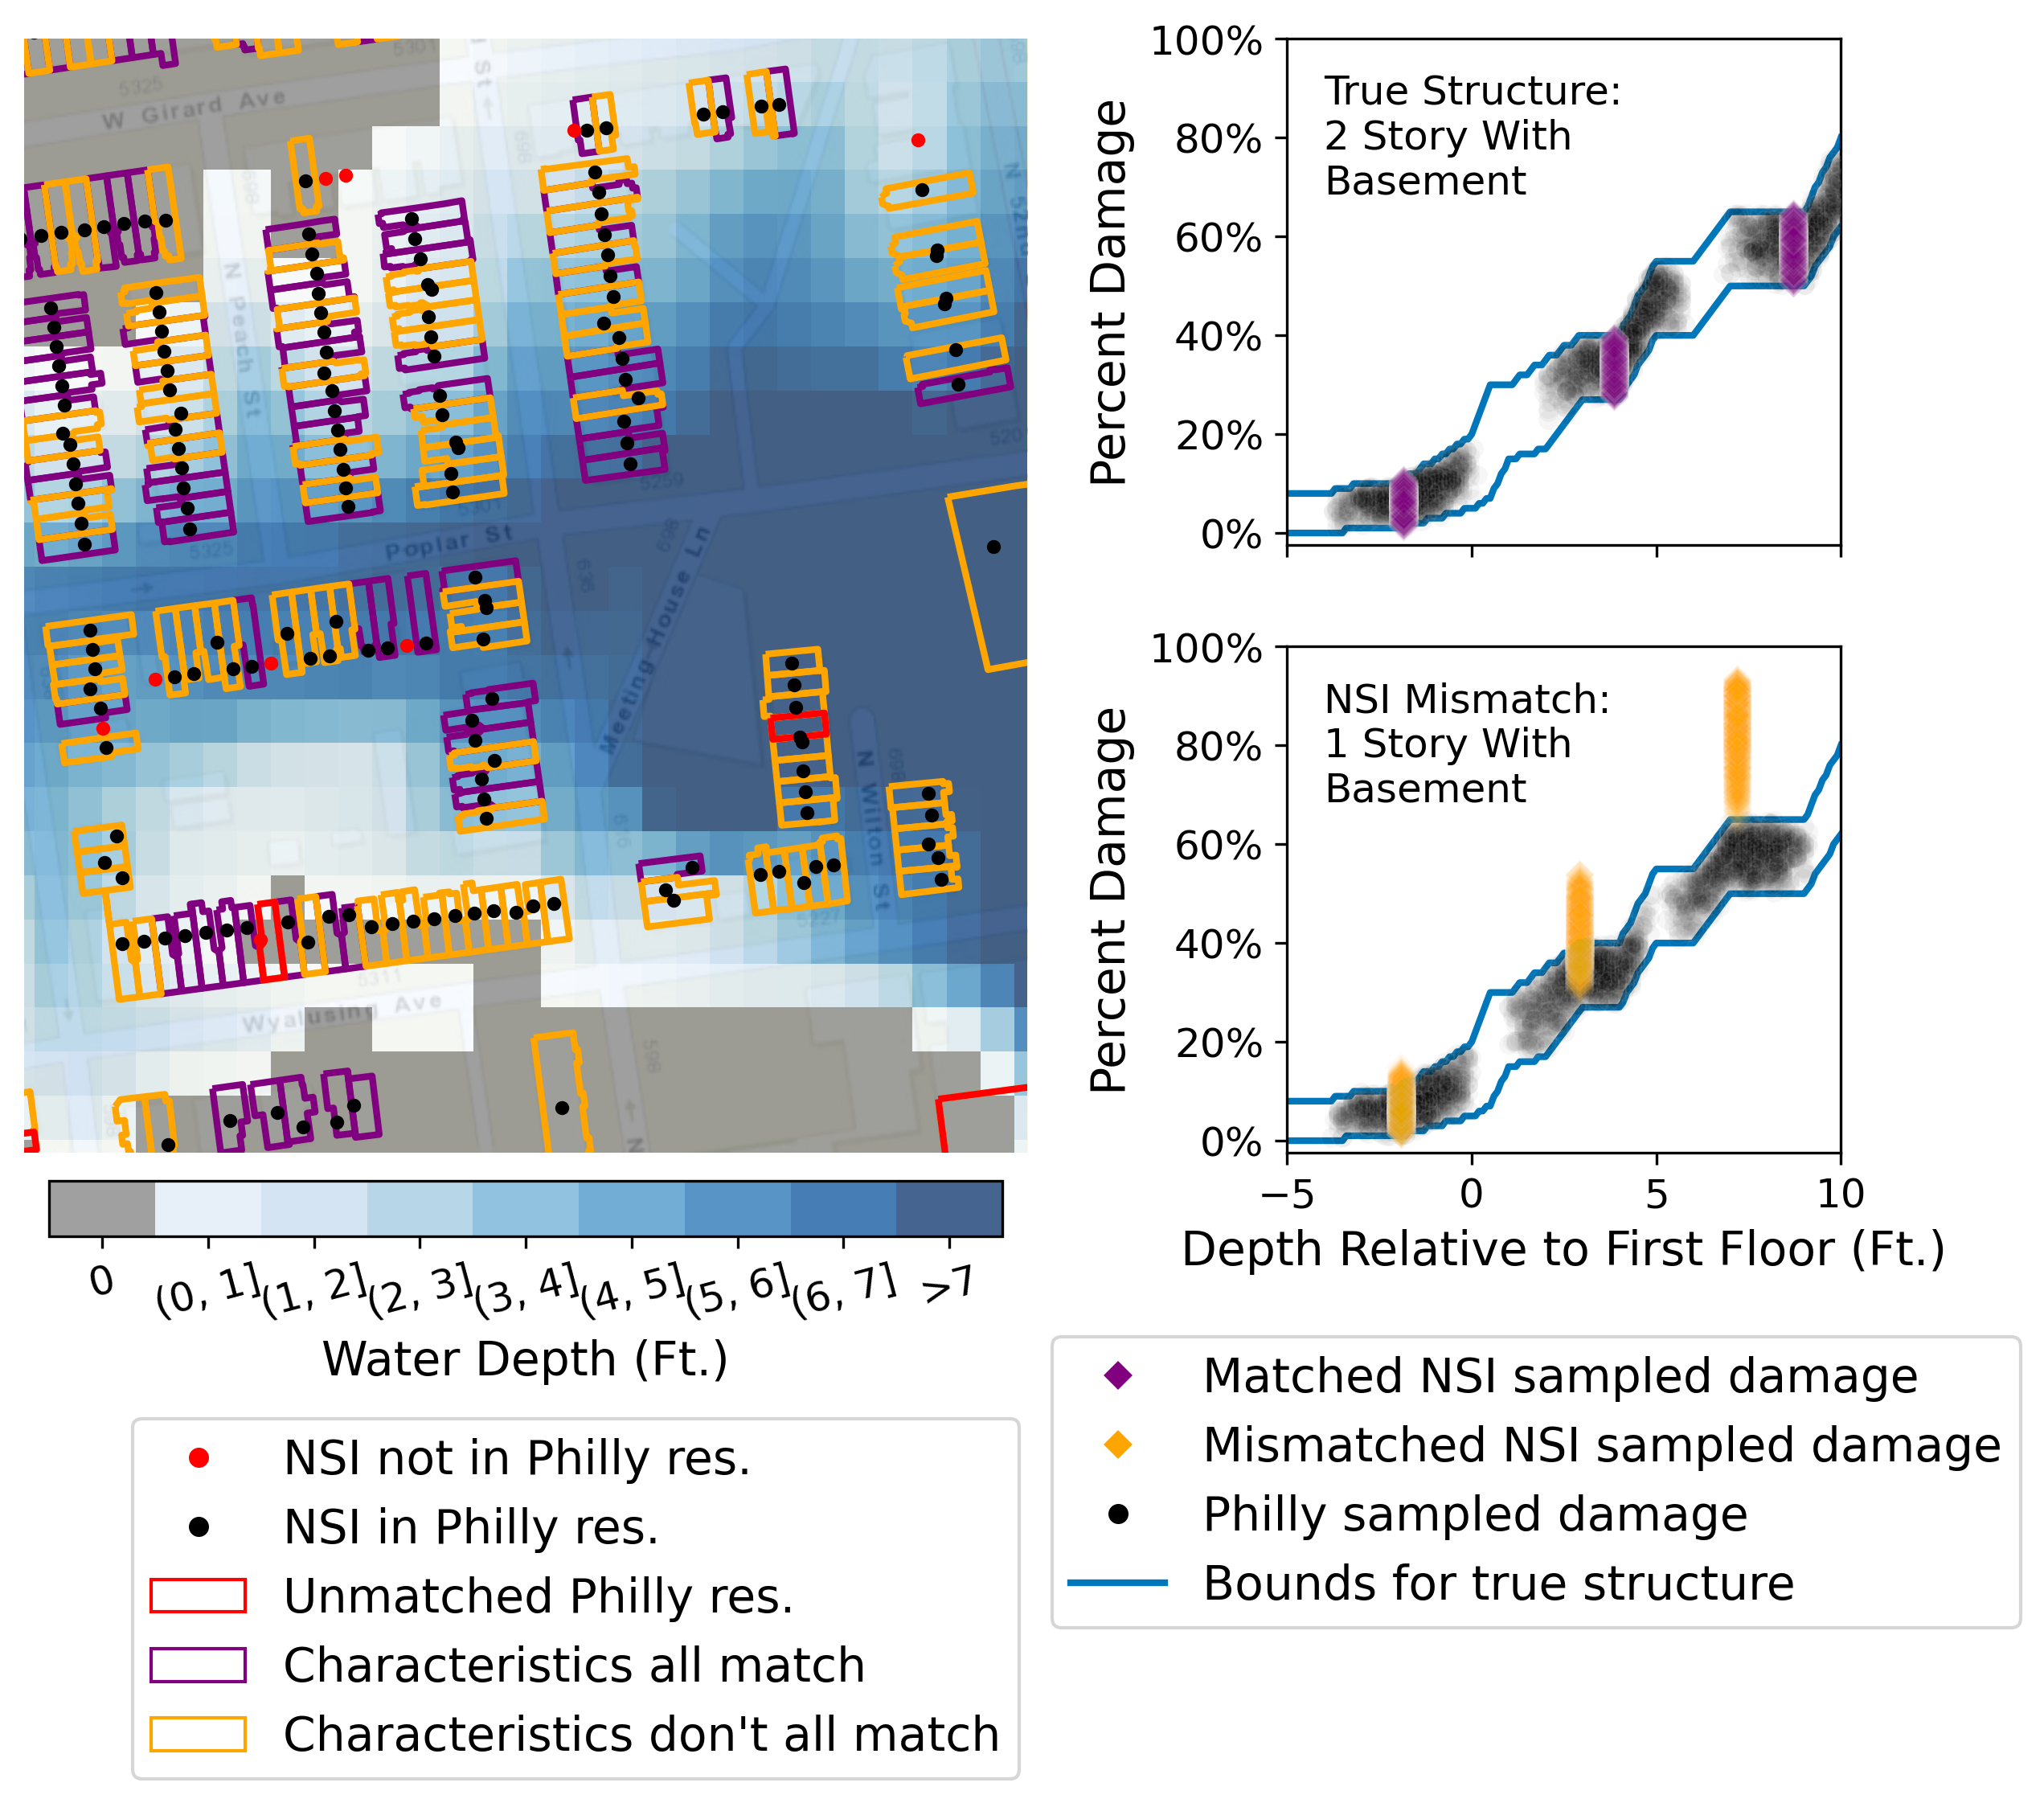

In [40]:
# Load DDFs for plotting
naccs_ddfs = pd.read_parquet(join(VULN_DIR_I, 'physical', 'naccs_ddfs.pqt'))

naccs_2swb = naccs_ddfs[naccs_ddfs['ddf_type'] == '2SWB_RES1']
# Add low/mid/high to naccs_plot
naccs_2swb[['low', 'mid', 'high']] = pd.DataFrame(naccs_2swb['params'].tolist(),
                                                    index=naccs_2swb.index)

naccs_1swb = naccs_ddfs[naccs_ddfs['ddf_type'] == '1SWB_RES1']
# Add low/mid/high to naccs_plot
naccs_1swb[['low', 'mid', 'high']] = pd.DataFrame(naccs_1swb['params'].tolist(),
                                                    index=naccs_1swb.index)

# Create figure with custom grid layout
fig = plt.figure(figsize=(10, 6), dpi=300)

# Create a 2-row grid with the top row for spatial plot and bottom row for damage functions
# The bottom row will be split into two equal columns
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], width_ratios=[2, 1],
                       wspace=.25)

# Create the spatial plot in the top row spanning both columns
ax_spatial = fig.add_subplot(gs[:, 0])

# Create the two damage function plots in the bottom row
ax_match = fig.add_subplot(gs[0, 1])
ax_mismatch = fig.add_subplot(gs[1, 1])

# SPATIAL PLOT CODE
cmap_with_zero = plt.cm.get_cmap('Blues').copy()
cmap_with_zero.set_bad('gray')

# Create a mask for zero values
zero_mask = clipped_dg[0] <= 0.01
da_masked = clipped_dg[0].where(~zero_mask)

# Plot the masked data
fg = (da_masked*3.28084).plot(ax=ax_spatial, cmap=cmap_with_zero, alpha=.75,
                              add_colorbar=False,
                              vmin=0, vmax=8)

phil_temp[phil_temp['match'] == 'All'].plot(ax=ax_spatial, lw=2, edgecolor='purple', color='none')
phil_temp[phil_temp['match'] != 'All'].plot(ax=ax_spatial, lw=2, edgecolor='orange', color='none')
phil_temp[phil_temp['match'] == 'Unmatched Philly'].plot(ax=ax_spatial, lw=2, edgecolor='red', color='none')
nsi_temp[nsi_temp['match'] != 'NSI Not In Philly'].plot(ax=ax_spatial, color='black', markersize=10)
nsi_temp[nsi_temp['match'] == 'NSI Not In Philly'].plot(ax=ax_spatial, color='red', markersize=10)

ax_spatial.axis('off')
# ax_spatial.set_title('Spatial Distribution of\nBuildings and Flood Depths', size=16, pad=15)
ax_spatial.set_title('')

ax_spatial.set_xlim([-.0085-7.522e1, -.00575-7.522e1])

ax_spatial.set_ylim([39.969, 39.97134])

# ax_spatial.set_ylim([39.965, 39.9698])
cx.add_basemap(ax_spatial,
               attribution=False,
               source=cx.providers.Esri.WorldStreetMap,
               crs=phil_temp.crs)

# cx.add_basemap(ax_spatial,
#                source=cx.providers.Esri.WorldImagery,
#                attribution=False,
#                crs=phil_temp.crs)

cbax = ax_spatial.inset_axes([0.025, -0.075, 0.95, 0.05])

# Create a new colormap that includes gray at the bottom
colors_list = ['gray'] + [cmap_with_zero(i) for i in range(cmap_with_zero.N)]
custom_cmap = colors.ListedColormap(colors_list)

# Create a custom normalization that maps -1 to gray and 0-8 to the Blues colormap
norm = colors.BoundaryNorm([-1, 0, 1, 2, 3, 4, 5, 6, 7, 8], custom_cmap.N)

# Create the colorbar with the custom colormap and norm
cbar = ColorbarBase(cbax, cmap=custom_cmap, norm=norm, 
                    orientation='horizontal',
                    alpha=0.75)

# Set the ticks and labels
cbar.set_ticks(np.arange(-.5, 8, 1))
cbar.set_ticklabels(['0', '(0, 1]', '(1, 2]', '(2, 3]', '(3, 4]',
                     '(4, 5]', '(5, 6]', '(6, 7]', '>7'],
                     rotation=15)
cbar.minorticks_off()

# Customize the colorbar appearance
cbar.ax.tick_params(labelsize=12)
cbar.set_label(label='Water Depth (Ft.)',
              size=14)

# fig.colorbar(fg,
#              ax=ax_spatial,
#              cax=cbax,
#              orientation='horizontal',
#              norm=norm,
#              # shrink=.8,
#              # anchor=(.8, .9),
#              # pad=.05,
#              # fraction=.05
#              extend='max',
#              label='Water Depth (Ft.)')
# fg.colorbar.ax.tick_params(labelsize=12)
# fg.colorbar.set_label(label='Water Depth (Ft.)',
#                      size=14)

# Spatial plot legend
spatial_legend_elements = [
    Line2D([0], [0], marker='o', ls='',
          color='red',
          label='NSI not in Philly res.',
          markerfacecolor='red',
          markersize=5),
    Line2D([0], [0], marker='o', ls='',
          color='black',
          label='NSI in Philly res.',
          markerfacecolor='black',
          markersize=5),
    Patch(facecolor='none', edgecolor='red',
         label='Unmatched Philly res.'),
    Patch(facecolor='none', edgecolor='purple',
         label='Characteristics all match'),
    Patch(facecolor='none', edgecolor='orange',
         label='Characteristics don\'t all match')
]

# Position the spatial legend at the bottom of the spatial plot
ax_spatial.legend(handles=spatial_legend_elements,
                 loc='center',
                 fontsize=14,
                 bbox_to_anchor=(0.55, -0.4),
                 ncol=1)

# DAMAGE FUNCTION PLOTS

# Define variables and data
bfids = [7648, 27706, 25078]
bfids_m = [1483, 27705, 16336]

# Plot for matched buildings
# naccs_2snb.plot(x='depth_ft',
#                y='mid',
#                ax=ax_match,
#                lw=1,
#                ls='dashed',
#                color='#0077BB')

for y_name in ['low', 'high']:
    naccs_2swb.plot(x='depth_ft',
                   y=y_name,
                   ax=ax_match,
                   lw=2,
                   ls='solid',
                   color='#0077BB')

for i, bfid in enumerate(bfids):
    nsi_bfid_plot = nsi_ddf_unc[nsi_ddf_unc['bfid'] == bfid]
    nsi_bfid_plot['d_adj'] = nsi_bfid_plot[dg_id] - nsi_bfid_plot['ffe']
    
    phil_bfid_plot = main_phil[main_phil['bfid'] == bfid]
    phil_bfid_plot['d_adj'] = phil_bfid_plot[dg_id] - phil_bfid_plot['ffe']
    
    sns.scatterplot(data=phil_bfid_plot,
                   x='d_adj',
                   y='rel_loss',
                   color='black',
                   ax=ax_match,
                   zorder=10,
                   alpha=.035,)
    
    sns.scatterplot(data=nsi_bfid_plot,
                   x='d_adj',
                   marker='D',
                   y='rel_loss',
                   color='purple',
                   zorder=10,
                   ax=ax_match,
                   alpha=.035,)

# Plot for mismatched buildings
# naccs_3snb.plot(x='depth_ft',
#                y='mid',
#                ax=ax_mismatch,
#                lw=1,
#                ls='dashed',
#                color='#0077BB')

for y_name in ['low', 'high']:
    naccs_2swb.plot(x='depth_ft',
                   y=y_name,
                   ax=ax_mismatch,
                   lw=2,
                   ls='solid',
                   color='#0077BB')

for i, bfid in enumerate(bfids_m):
    nsi_bfid_plot = nsi_ddf_unc[nsi_ddf_unc['bfid'] == bfid]
    nsi_bfid_plot['d_adj'] = nsi_bfid_plot[dg_id] - nsi_bfid_plot['ffe']
    
    phil_bfid_plot = main_phil[main_phil['bfid'] == bfid]
    phil_bfid_plot['d_adj'] = phil_bfid_plot[dg_id] - phil_bfid_plot['ffe']
    
    sns.scatterplot(data=phil_bfid_plot,
                   x='d_adj',
                   y='rel_loss',
                   color='black',
                   ax=ax_mismatch,
                   zorder=10,
                   alpha=.035,)
    sns.scatterplot(data=nsi_bfid_plot,
                   x='d_adj',
                   y='rel_loss',
                   marker='D',
                   color='orange',
                   zorder=10,
                   ax=ax_mismatch,
                   alpha=.035,)

# Configure both damage function plots
for ax, title in zip([ax_match, ax_mismatch], 
                     ['Examples Of Depth\nDamage Function Match', 
                      'Examples Of Depth\nDamage Function Mismatch']):
    ax.set_ylim([-.025, 1])
    #xlow = naccs_2swb[naccs_2swb['high'] == 0]['depth_ft'].max() - .5
    xhigh = naccs_2swb['depth_ft'].max()
    
    # Remove auto-generated legends
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    
    ax.set_xlim([-5, xhigh])
    # ax.set_title(title, size=14)

ax_mismatch.set_xlabel('Depth Relative to First Floor (Ft.)', size=14)
ax_mismatch.tick_params('both', labelsize=12)
ax_match.tick_params('y', labelsize=12)
ax_match.set_xlabel('')
ax_match.tick_params('x', which='both', labelbottom=False)

# Only set y-label on the left plot
ax_match.set_ylabel('Percent Damage', size=14)
ax_mismatch.set_ylabel('Percent Damage', size=14)
ax_match.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, symbol='%', decimals=0))
ax_mismatch.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, symbol='%', decimals=0))

# Remove y-tick labels from right plot
# ax_mismatch.tick_params(axis='y', which='both', labelleft=False)

# Create legend for damage function plots
damage_legend_elements = [
    Line2D([0], [0], marker='D', ls='',
          color='purple',
          label='Matched NSI sampled damage',
          markerfacecolor='purple',
          markersize=5),
    Line2D([0], [0], marker='D', ls='',
          color='orange',
          label='Mismatched NSI sampled damage',
          markerfacecolor='orange',
          markersize=5),
    Line2D([0], [0], marker='o', ls='',
          color='black',
          label='Philly sampled damage',
          markerfacecolor='black',
          markersize=5),
    Line2D([0], [0], marker='', ls='-',
          lw=2,
          color='#0077BB',
          alpha=1,
          label='Bounds for true structure'),
]

# Add the damage function legend between the two bottom plots
ax_mismatch.legend(handles=damage_legend_elements,
          loc='center',
          ncol=1,
          fontsize=14,
          bbox_to_anchor=(0.45, -0.65))

# Add annotations
ax_match.annotate('True Structure:\n2 Story With\nBasement',
                 xy=(-4., .8),
                 xycoords='data',
                 horizontalalignment='left',
                 verticalalignment='center',
                 size=12)

ax_mismatch.annotate('NSI Mismatch:\n1 Story With\nBasement',
                    xy=(-4., .8),
                    xycoords='data',
                    horizontalalignment='left',
                    verticalalignment='center',
                    size=12)

fig.savefig(join(FIG_DIR, 'fig1.png'), bbox_inches='tight', dpi=300)

/var/folders/d2/g0h08s551zb2hz_ws2g4ggh400hbd0/T/ipykernel_44772/2578803537.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_with_zero = plt.cm.get_cmap('Blues').copy()


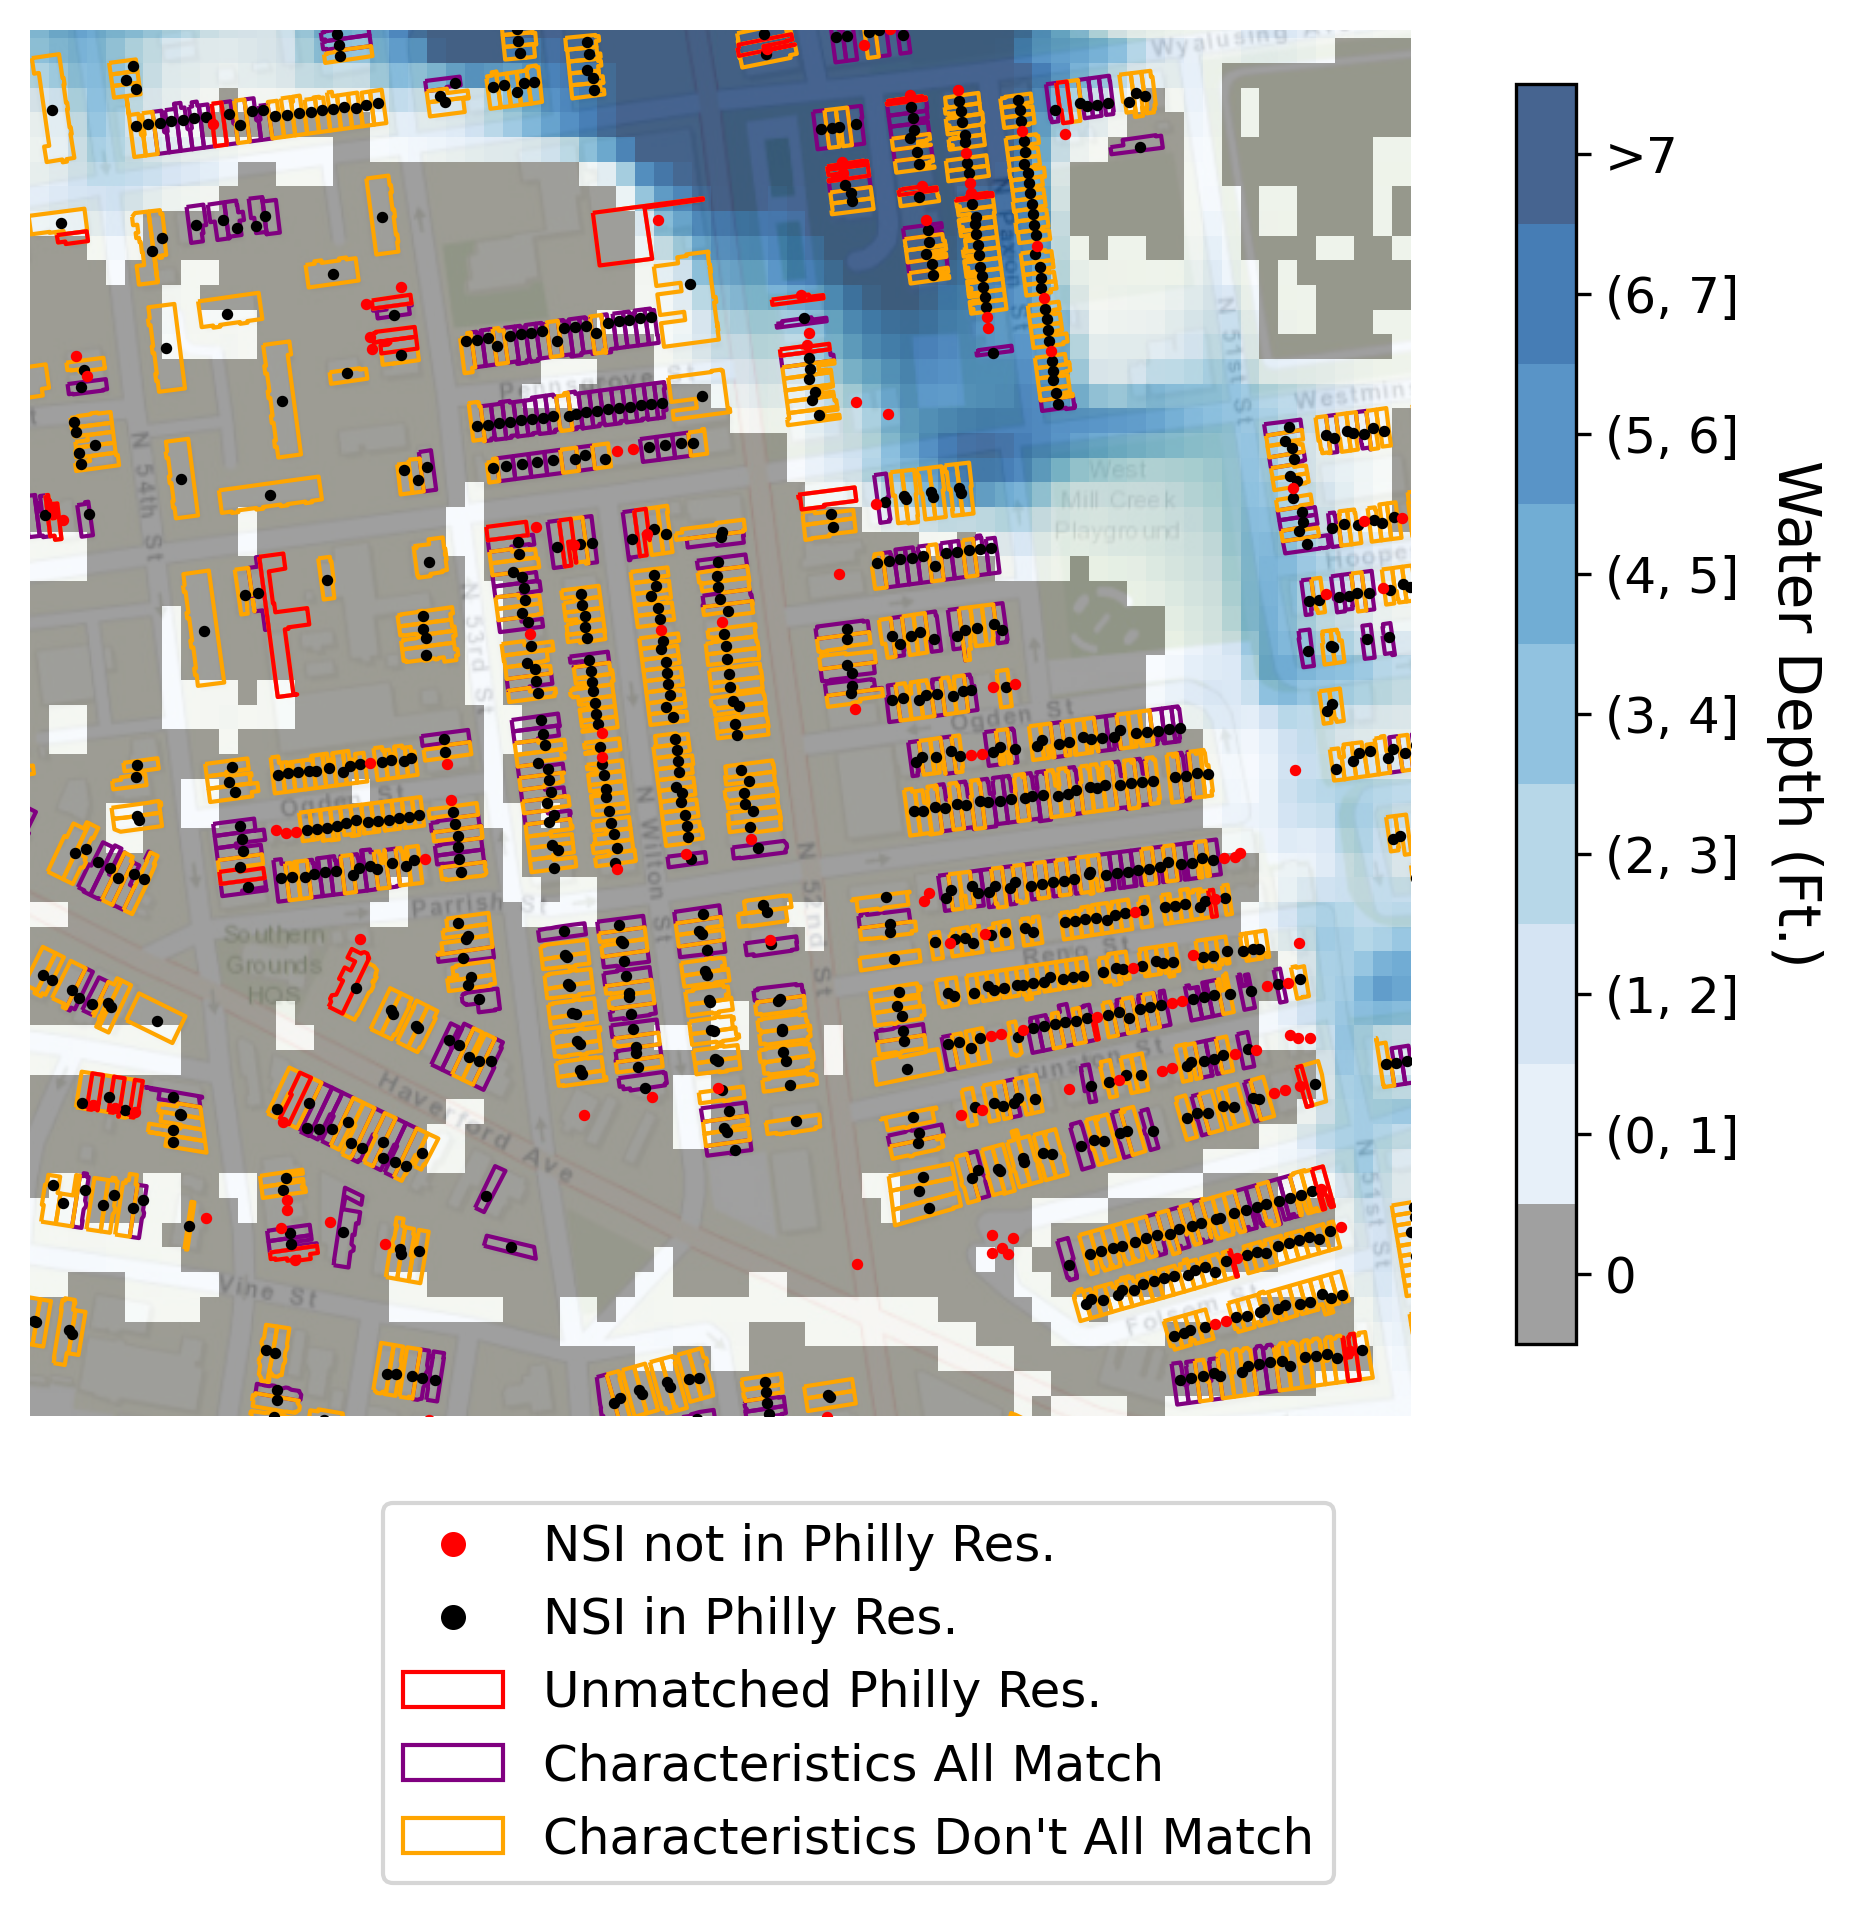

In [41]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# Create a custom colormap with the zero_color for masked values
cmap_with_zero = plt.cm.get_cmap('Blues').copy()
cmap_with_zero.set_bad('gray')

# Create a mask for zero values
zero_mask = clipped_dg <= .01
da_masked = clipped_dg[0].where(~zero_mask)

# Plot the masked data
fg = (da_masked*3.28404).plot(ax=ax, cmap=cmap_with_zero, alpha=.75,
                                 vmin=0, vmax=8)

phil_temp[phil_temp['match'] == 'All'].plot(ax=ax, edgecolor='purple', color='none')
phil_temp[phil_temp['match'] != 'All'].plot(ax=ax, edgecolor='orange', color='none')
phil_temp[phil_temp['match'] == 'Unmatched Philly'].plot(ax=ax, edgecolor='red', color='none')
nsi_temp[nsi_temp['match'] != 'NSI Not In Philly'].plot(ax=ax, color='black', markersize=3)
nsi_temp[nsi_temp['match'] == 'NSI Not In Philly'].plot(ax=ax, color='red', markersize=3)

ax.axis('off')
ax.set_ylim([39.9646, 39.9698])
cx.add_basemap(ax,
               attribution=False,
               source=cx.providers.Esri.WorldStreetMap,
               crs=phil_temp.crs)
ax.set_title('')

# Remove the automatically created colorbar
fig.delaxes(fig.axes[-1])

# Create a new axis for the colorbar with extra space at the bottom for the no-data entry
cbar_ax = fig.add_axes([0.78, 0.15, 0.02, 0.7])  # [left, bottom, width, height]

# Create a new colormap that includes gray at the bottom
colors_list = ['gray'] + [cmap_with_zero(i) for i in range(cmap_with_zero.N)]
custom_cmap = colors.ListedColormap(colors_list)

# Create a custom normalization that maps -1 to gray and 0-8 to the Blues colormap
norm = colors.BoundaryNorm([-1, 0, 1, 2, 3, 4, 5, 6, 7, 8], custom_cmap.N)

# Create the colorbar with the custom colormap and norm
cbar = ColorbarBase(cbar_ax, cmap=custom_cmap, norm=norm, 
                    orientation='vertical', alpha=0.75)

# Set the ticks and labels
cbar.set_ticks(np.arange(-.5, 8, 1))
cbar.set_ticklabels(['0', '(0, 1]', '(1, 2]', '(2, 3]', '(3, 4]',
                     '(4, 5]', '(5, 6]', '(6, 7]', '>7'],)
cbar.minorticks_off()

# Customize the colorbar appearance
cbar.ax.tick_params(labelsize=12)
cbar.set_label(label='Water Depth (Ft.)', 
              rotation=270, 
              labelpad=20, 
              size=14)

legend_elements = [Line2D([0], [0], marker='o', ls='',
                          color='red',
                          label='NSI not in Philly Res.',
                          markerfacecolor='red', 
                          markersize=5),
                    Line2D([0], [0], marker='o', ls='',
                          color='black',
                          label='NSI in Philly Res.',
                          markerfacecolor='black',
                          markersize=5),
                   Patch(facecolor='none', edgecolor='red',
                         label='Unmatched Philly Res.'),
                    Patch(facecolor='none', edgecolor='purple',
                         label='Characteristics All Match'),
                    Patch(facecolor='none', edgecolor='orange',
                         label='Characteristics Don\'t All Match')]

ax.legend(handles=legend_elements,
          loc='center',
          fontsize=12,
          bbox_to_anchor=(.6, -.2))

fig.savefig(join(FIG_DIR, 'fig1_supp.png'), bbox_inches='tight', dpi=300)

### Figure 2
Damage discrepancies across structure inventories by match type and flood depth. Panel A shows the distribution of differences between National Structure Inventory (NSI) and Philadelphia ensembles' mean damage estimates. The red diamonds indicate the mean for each match type and flood depth subgroup. Panel B shows the count of each match type for each flood depth subgroup. Panel C shows the mean cumulative damage discrepancy across the ensemble over depths for each match type and in aggregate. 

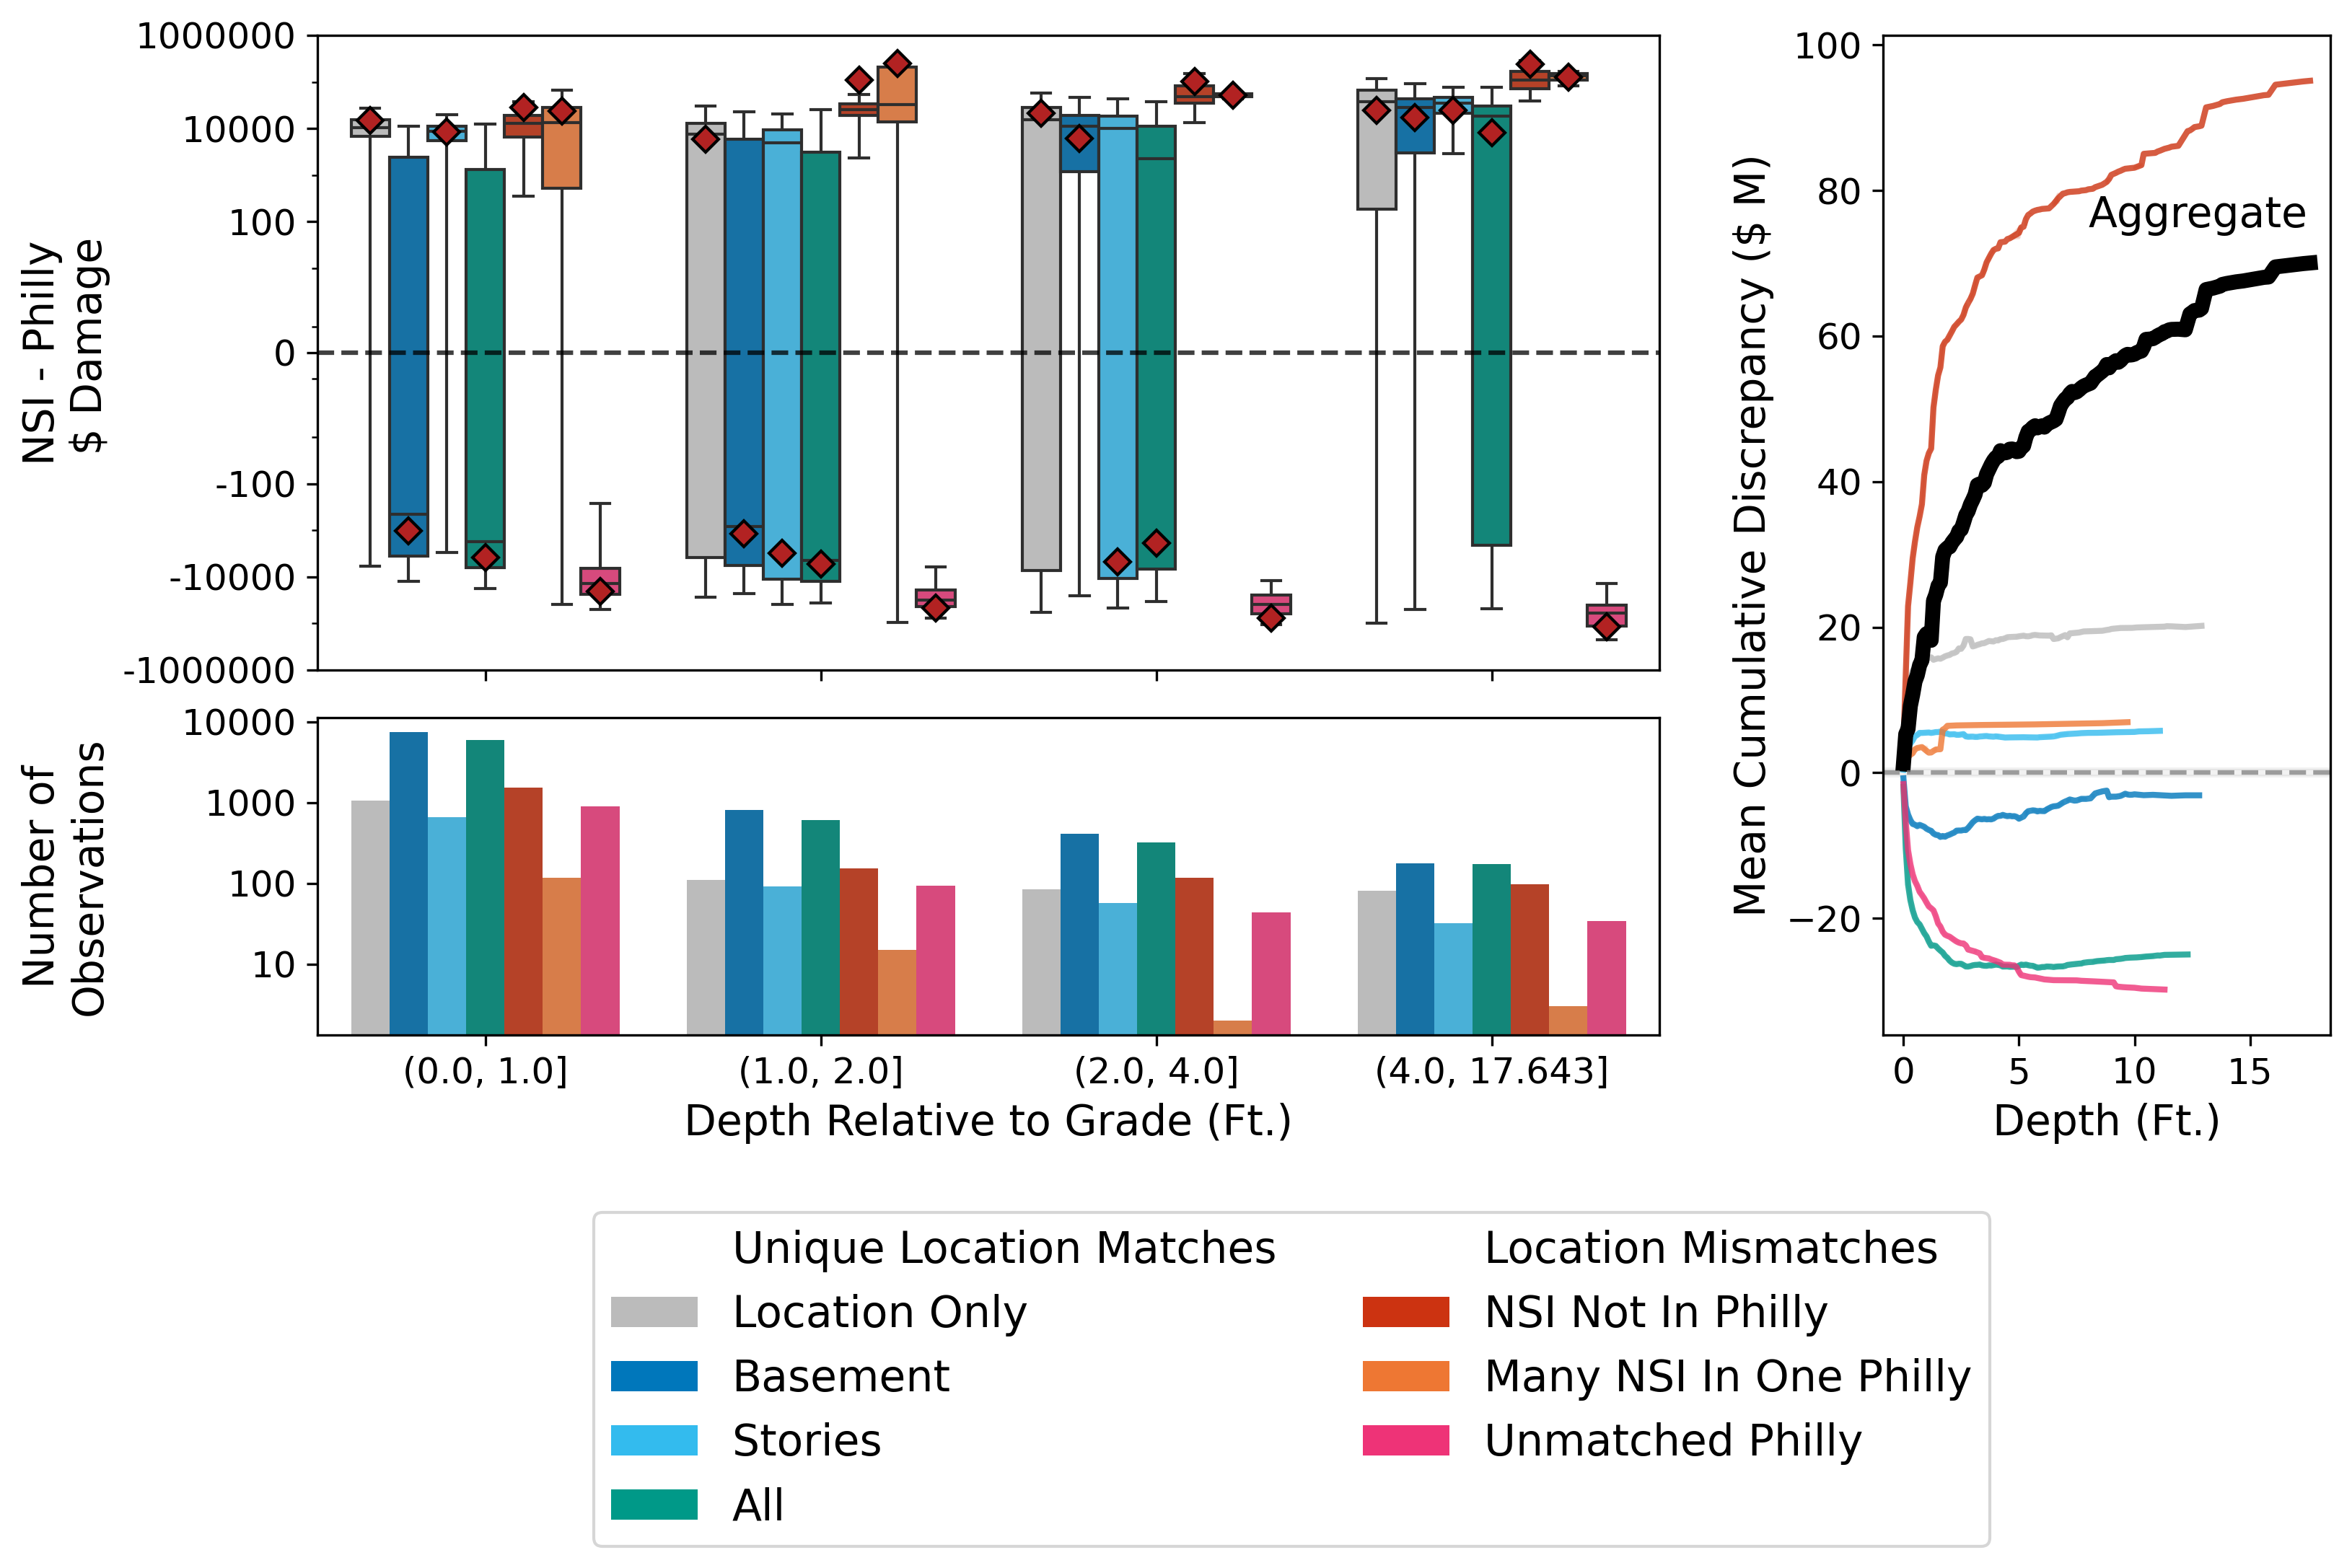

In [42]:
# Define consistent order for better visual alignment
hue_order = ['Location Only',
             'Basement',
             'Stories',
             'All',
             'NSI Not In Philly',
             'Many NSI In One Philly',
             'Unmatched Philly']

# Define a colormap that groups matches and non matches together thematically
palette_dict = {'Location Only': '#BBBBBB',
                'Basement': '#0077BB',
                'Stories': '#33BBEE',
                'All': '#009988',
                'NSI Not In Philly': '#CC3311',
                'Many NSI In One Philly': '#EE7733',
                'Unmatched Philly': '#EE3377'}

# Create figure with custom grid layout
fig = plt.figure(figsize=(12, 6), dpi=300)
gs = gridspec.GridSpec(2, 2, height_ratios=[2, 1],
                       width_ratios=[3, 1],
                       wspace=.25,
                       hspace=0.1)

# Left column - original 3×1 layout
ax1 = fig.add_subplot(gs[0, 0])  # Top - absolute difference
ax2 = fig.add_subplot(gs[1, 0])  # Bottom - counts
ax4 = fig.add_subplot(gs[:, 1])

# Top: Absolute difference boxplot
sns.boxplot(data=test_gb,
           x='depth_bins',
           y='diff',
           hue='Matches',
           hue_order=hue_order,
           palette=palette_dict,
           showfliers=False,
           showmeans=True,
           meanprops={'markerfacecolor': 'firebrick',
                      'markeredgecolor': 'black', 'marker': 'D'},
           legend=True,
           ax=ax1)

ax1.axhline(0, color='black', ls='--', alpha=.75)
ax1.set_xlabel('')  # Remove x-label as it's shared
ax1.set_ylabel('NSI - Philly\n $ Damage', size=14)
ax1.set_yscale('symlog')
ax1.set_ylim([-10e5, 10e5])
ax1.set_yticks([-1e6, -1e4, -1e2, 0, 1e2, 1e4, 1e6])
# Remove x-tick labels for middle row
ax1.set_xticklabels([])

# Bottom: Count plot
sns.countplot(data=test_gb,
             x='depth_bins',
             hue='Matches',
             hue_order=hue_order,
             palette=palette_dict,
             legend=False,
             ax=ax2)

ax2.set_yscale('log')

# Define formatter
def format_func(value, tick_number):
    return f'{int(value)}'

# Apply formatter
formatter = FuncFormatter(format_func)
ax1.yaxis.set_major_formatter(formatter)
ax2.yaxis.set_major_formatter(formatter)

ax2.minorticks_off()
ax2.set_xlabel('Depth Relative to Grade (Ft.)', size=14)
ax2.set_ylabel('Number of\nObservations', size=14)


# Align y-labels
fig.align_ylabels([ax1, ax2])

# Panel 4: Cumulative discrepancy plot (right side)
# Let seaborn handle the categories directly
sns.lineplot(data=test_gb,
            x='depth_plot',
            y='cm_diff',
            hue='Matches',
            hue_order=hue_order,
            palette=palette_dict,
            ax=ax4,
            alpha=0.8,
            legend=False,
            linewidth=2)

# Add the overall discrepancy line with enhanced styling
sns.lineplot(data=test_gb,
            x='depth_plot',
            y='cm_diff_agg',
            color='black',
            lw=5,
            label='Overall Discrepancy',
            legend=False,
            ax=ax4)

# Improve the cumulative plot styling
ax4.axhline(0, color='gray', ls='--', alpha=.75, linewidth=1.5)
ax4.set_ylabel('Mean Cumulative Discrepancy ($ M)', size=14)
ax4.set_xlabel('Depth (Ft.)', size=14)
# ax4.axvline(1, color='black', linestyle='--', alpha=.3)

# Add a shaded region around the zero line to emphasize the crossing points
ax4.axhspan(-0.5, 0.5, color='gray', alpha=0.1)

# Optimize legend placement - centered at bottom
# handles, labels = ax1.get_legend_handles_labels()
ax1.legend_.remove()  # Remove the original legend

legend_elements = [Patch(facecolor='none', edgecolor='none',
                         label='Unique Location Matches'),
                   Patch(facecolor=palette_dict['Location Only'],
                         label='Location Only'),
                   Patch(facecolor=palette_dict['Basement'],
                         label='Basement'),
                  Patch(facecolor=palette_dict['Stories'],
                         label='Stories'),
                   Patch(facecolor=palette_dict['All'],
                         label='All'),
                   Patch(facecolor='none', edgecolor='none',
                         label='Location Mismatches'),
                   Patch(facecolor=palette_dict['NSI Not In Philly'],
                         label='NSI Not In Philly'),
                         Patch(facecolor=palette_dict['Many NSI In One Philly'],
                         label='Many NSI In One Philly'),
                   Patch(facecolor=palette_dict['Unmatched Philly'],
                         label='Unmatched Philly'),]

legend = fig.legend(handles=legend_elements,# handles, labels,
                    # title='Location and Characteristic Matches',
                    title_fontsize='x-large',
                    fontsize='x-large', 
                    loc='upper center',
                    bbox_to_anchor=(0.5, -0.01), 
                    ncol=2) 


# Add the annotation label
ax4.annotate('Aggregate', 
            xy=(8, 75),  # Point to annotate
            fontsize=14)

# Adjust tick sizes
for ax in [ax1, ax2, ax4]:
    ax.tick_params(labelsize=12)

fig.savefig(join(FIG_DIR, 'fig2.png'), bbox_inches='tight', dpi=300)

In [ ]:
# Define consistent order for better visual alignment
hue_order = ['Occupancy',
             'Basement & Occupancy',
             'Stories & Occupancy',
             'Basement',
             'Stories',
             'Basement & Stories',]

# Define a colormap that groups matches and non matches together thematically
palette_dict = {'Basement': '#0077BB',
                'Basement & Stories': '#33BBEE',
                'Basement & Occupancy': '#CC3311',
                'Stories': '#009988',
                'Occupancy': '#EE7733',
                'Stories & Occupancy': '#EE3377'}


# Create figure with custom grid layout
fig = plt.figure(figsize=(10, 6), dpi=300)
gs = gridspec.GridSpec(2, 1,
                       wspace=.25,
                       hspace=0.1)

# Left column - original 3×1 layout
ax1 = fig.add_subplot(gs[0])  # Top - absolute difference
ax2 = fig.add_subplot(gs[1])  # Bottom - counts

# Top: Absolute difference boxplot
sns.boxplot(data=test_gb,
           x='depth_bins',
           y='diff',
           hue='Structure Matches',
           hue_order=hue_order,
           palette=palette_dict,
           showfliers=False,
           showmeans=True,
           meanprops={'markerfacecolor': 'firebrick',
                      'markeredgecolor': 'black', 'marker': 'D'},
           legend=True,
           ax=ax1)

ax1.axhline(0, color='black', ls='--', alpha=.75)
ax1.set_xlabel('')  # Remove x-label as it's shared
ax1.set_ylabel('NSI - Philly\n $ Damage', size=14)
ax1.set_yscale('symlog')
ax1.set_ylim([-10e5, 10e5])
ax1.set_yticks([-1e6, -1e4, -1e2, 0, 1e2, 1e4, 1e6])
# Remove x-tick labels for middle row
ax1.set_xticklabels([])

# Bottom: Count plot
sns.countplot(data=test_gb,
             x='depth_bins',
             hue='Structure Matches',
             hue_order=hue_order,
             palette=palette_dict,
             legend=False,
             ax=ax2)

ax2.set_yscale('log')

# Define formatter
def format_func(value, tick_number):
    return f'{int(value)}'

# Apply formatter
formatter = FuncFormatter(format_func)
ax1.yaxis.set_major_formatter(formatter)
ax2.yaxis.set_major_formatter(formatter)

ax2.minorticks_off()
ax2.set_xlabel('Depth Relative to Grade (Ft.)', size=14)
ax2.set_ylabel('Number of\nObservations', size=14)


# Align y-labels
fig.align_ylabels([ax1, ax2])

# # Panel 4: Cumulative discrepancy plot (right side)
# # Let seaborn handle the categories directly
# sns.lineplot(data=test_gb,
#             x='depth_plot',
#             y='cm_diff',
#             hue='Structure Matches',
#             hue_order=hue_order,
#             palette=palette_dict,
#             ax=ax4,
#             alpha=0.8,
#             legend=False,
#             linewidth=2)

# # Add the overall discrepancy line with enhanced styling
# sns.lineplot(data=test_gb,
#             x='depth_plot',
#             y='cm_diff_agg',
#             color='black',
#             lw=5,
#             label='Overall Discrepancy',
#             legend=False,
#             ax=ax4)

# # Improve the cumulative plot styling
# ax4.axhline(0, color='gray', ls='--', alpha=.75, linewidth=1.5)
# ax4.set_ylabel('Mean Cumulative Discrepancy ($ M)', size=14)
# ax4.set_xlabel('Depth (Ft.)', size=14)
# # ax4.axvline(1, color='black', linestyle='--', alpha=.3)

# # Add a shaded region around the zero line to emphasize the crossing points
# ax4.axhspan(-0.5, 0.5, color='gray', alpha=0.1)

# Optimize legend placement - centered at bottom
# handles, labels = ax1.get_legend_handles_labels()
ax1.legend_.remove()  # Remove the original legend

legend_elements = [Patch(facecolor=palette_dict[x],
                         edgecolor='none',
                         label=x) for x in hue_order]

legend = fig.legend(handles=legend_elements,# handles, labels,
                    title='Characteristic Matches',
                    title_fontsize='x-large',
                    fontsize='x-large', 
                    loc='upper center',
                    bbox_to_anchor=(0.5, -0.01), 
                    ncol=2) 


# Add the annotation label
# ax4.annotate('Aggregate', 
#             xy=(8, 75),  # Point to annotate
#             fontsize=14)

# Adjust tick sizes
for ax in [ax1, ax2]:
    ax.tick_params(labelsize=12)

# fig.savefig(join(FIG_DIR, 'fig2_supp_loc_subset.png'), bbox_inches='tight', dpi=300)

In [ ]:
hue_order = ['Location Only',
             'Location & Subset',
             'All',
             'NSI Not In Philly',
             'Many NSI In One Philly',
             'Unmatched Philly']

# Define a colormap that groups matches and non matches together thematically
palette_dict = {'Location Only': '#0077BB',
                'Location & Subset': '#33BBEE',
                'All': '#009988',
                'NSI Not In Philly': '#CC3311',
                'Many NSI In One Philly': '#EE7733',
                'Unmatched Philly': '#EE3377'}

# For this plot, it's most important to focus on the depths with
# the most observations to avoid skew on the top panel
test_gb_sub = test_gb[test_gb['depth_plot'] < 4]
test_gb_sub['depth_bins'] = test_gb_sub['depth_bins'].cat.remove_categories([pd.Interval(4.0, 17.643)])

# Create figure with custom grid layout
fig = plt.figure(figsize=(10, 8), dpi=300)
gs = gridspec.GridSpec(3, 1,
                       wspace=.25,
                       hspace=0.1)

# Left column - original 3×1 layout
ax2 = fig.add_subplot(gs[2])  # bottom - absolute difference
ax1 = fig.add_subplot(gs[1])  # mid - vals
ax0 = fig.add_subplot(gs[0])  # top - rel dam

# Bottom: Absolute difference boxplot
sns.boxplot(data=test_gb_sub,
           x='depth_bins',
           y='diff',
           hue='Matches',
           hue_order=hue_order,
           palette=palette_dict,
           showfliers=False,
           showmeans=True,
           meanprops={'markerfacecolor': 'firebrick',
                      'markeredgecolor': 'black', 'marker': 'D'},
           legend=False,
           ax=ax2)

ax2.axhline(0, color='black', ls='--', alpha=.75)
ax2.set_ylabel('NSI - Philly\n $ Damage', size=14)
ax2.set_yscale('symlog')
ax2.set_ylim([-15e5, 15e5])
ax2.set_yticks([-1e6, -1e4, -1e2, 0, 1e2, 1e4, 1e6])

# Mid - structure values
sns.boxplot(data=test_gb_sub,
           x='depth_bins',
           y='diff_val',
           hue='Matches',
           hue_order=hue_order,
           palette=palette_dict,
           showfliers=False,
           showmeans=True,
           meanprops={'markerfacecolor': 'firebrick',
                      'markeredgecolor': 'black', 'marker': 'D'},
           legend=False,
           ax=ax1)

ax1.set_yscale('symlog')
ax1.axhline(0, color='black', ls='--', alpha=.75)
ax1.set_ylabel('NSI - Philly\n $ Value', size=14)
ax1.set_ylim([-25e5, 25e5])
ax1.set_yticks([-1e6, -1e4, -1e2, 0, 1e2, 1e4, 1e6])
ax1.set_xticklabels([])
ax1.minorticks_off()

# Top - rel diff
sns.boxplot(data=test_gb_sub,
           x='depth_bins',
           y='diff_rel',
           hue='Matches',
           hue_order=hue_order,
           palette=palette_dict,
           showfliers=False,
           showmeans=True,
           meanprops={'markerfacecolor': 'firebrick',
                      'markeredgecolor': 'black', 'marker': 'D'},
           legend=True,
           ax=ax0)

ax0.axhline(0, color='black', ls='--', alpha=.75)
ax0.set_ylabel('NSI - Philly\n % Damage', size=14)
ax0.set_xticklabels([])
ax0.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, symbol='%', decimals=0))

# Define formatter
def format_func(value, tick_number):
    return f'{int(value)}'

# Apply formatter
formatter = FuncFormatter(format_func)
ax1.yaxis.set_major_formatter(formatter)
ax2.yaxis.set_major_formatter(formatter)

ax2.minorticks_off()
ax2.set_xlabel('Depth Relative to Grade (Ft.)', size=14)

ax0.set_xlabel('')
ax1.set_xlabel('')

# Align y-labels
fig.align_ylabels([ax0, ax1, ax2])

# # Panel 4: Cumulative discrepancy plot (right side)
# # Let seaborn handle the categories directly
# sns.lineplot(data=test_gb,
#             x='depth_plot',
#             y='cm_diff',
#             hue='Structure Matches',
#             hue_order=hue_order,
#             palette=palette_dict,
#             ax=ax4,
#             alpha=0.8,
#             legend=False,
#             linewidth=2)

# # Add the overall discrepancy line with enhanced styling
# sns.lineplot(data=test_gb,
#             x='depth_plot',
#             y='cm_diff_agg',
#             color='black',
#             lw=5,
#             label='Overall Discrepancy',
#             legend=False,
#             ax=ax4)

# # Improve the cumulative plot styling
# ax4.axhline(0, color='gray', ls='--', alpha=.75, linewidth=1.5)
# ax4.set_ylabel('Mean Cumulative Discrepancy ($ M)', size=14)
# ax4.set_xlabel('Depth (Ft.)', size=14)
# # ax4.axvline(1, color='black', linestyle='--', alpha=.3)

# # Add a shaded region around the zero line to emphasize the crossing points
# ax4.axhspan(-0.5, 0.5, color='gray', alpha=0.1)

# Optimize legend placement - centered at bottom
# handles, labels = ax1.get_legend_handles_labels()
ax0.legend_.remove()  # Remove the original legend


legend_elements = [Patch(facecolor='none', edgecolor='none',
                         label='Unique Location Matches'),
                   Patch(facecolor=palette_dict['Location Only'],
                         label='Location Only'),
                   Patch(facecolor=palette_dict['Location & Subset'],
                         label='Location & Subset'),
                   Patch(facecolor=palette_dict['All'],
                         label='All'),
                   Patch(facecolor='none', edgecolor='none',
                         label='Location Mismatches'),
                   Patch(facecolor=palette_dict['NSI Not In Philly'],
                         label='NSI Not In Philly'),
                         Patch(facecolor=palette_dict['Many NSI In One Philly'],
                         label='Many NSI In One Philly'),
                   Patch(facecolor=palette_dict['Unmatched Philly'],
                         label='Unmatched Philly'),]

legend = fig.legend(handles=legend_elements,# handles, labels,
                    # title='Location and Characteristic Matches',
                    title_fontsize='x-large',
                    fontsize='x-large', 
                    loc='upper center',
                    bbox_to_anchor=(0.5, -0.01), 
                    ncol=2) 


# Add the annotation label
# ax4.annotate('Aggregate', 
#             xy=(8, 75),  # Point to annotate
#             fontsize=14)

# Adjust tick sizes
for ax in [ax0, ax1, ax2]:
    ax.tick_params(labelsize=12)

# fig.savefig(join(FIG_DIR, 'fig2_supp_dlim.png'), bbox_inches='tight', dpi=300)

In [ ]:
hue_order = ['Location Only',
             'Location & Subset',
             'All',
             'NSI Not In Philly',
             'Many NSI In One Philly',
             'Unmatched Philly']

# Define a colormap that groups matches and non matches together thematically
palette_dict = {'Location Only': '#0077BB',
                'Location & Subset': '#33BBEE',
                'All': '#009988',
                'NSI Not In Philly': '#CC3311',
                'Many NSI In One Philly': '#EE7733',
                'Unmatched Philly': '#EE3377'}

# Create figure with custom grid layout
fig = plt.figure(figsize=(10, 8), dpi=300)
gs = gridspec.GridSpec(3, 1,
                       wspace=.25,
                       hspace=0.1)

# Left column - original 3×1 layout
ax2 = fig.add_subplot(gs[2])  # bottom - absolute difference
ax1 = fig.add_subplot(gs[1])  # mid - vals
ax0 = fig.add_subplot(gs[0])  # top - rel dam

# Bottom: Absolute difference boxplot
sns.boxplot(data=test_gb,
           x='depth_bins',
           y='diff',
           hue='Matches',
           hue_order=hue_order,
           palette=palette_dict,
           showfliers=False,
           showmeans=True,
           meanprops={'markerfacecolor': 'firebrick',
                      'markeredgecolor': 'black', 'marker': 'D'},
           legend=False,
           ax=ax2)

ax2.axhline(0, color='black', ls='--', alpha=.75)
ax2.set_ylabel('NSI - Philly\n $ Damage', size=14)
ax2.set_yscale('symlog')
ax2.set_ylim([-15e5, 15e5])
ax2.set_yticks([-1e6, -1e4, -1e2, 0, 1e2, 1e4, 1e6])

# Mid - structure values
sns.boxplot(data=test_gb,
           x='depth_bins',
           y='diff_val',
           hue='Matches',
           hue_order=hue_order,
           palette=palette_dict,
           showfliers=False,
           showmeans=True,
           meanprops={'markerfacecolor': 'firebrick',
                      'markeredgecolor': 'black', 'marker': 'D'},
           legend=False,
           ax=ax1)

ax1.set_yscale('symlog')
ax1.axhline(0, color='black', ls='--', alpha=.75)
ax1.set_ylabel('NSI - Philly\n $ Value', size=14)
ax1.set_ylim([-25e5, 25e5])
ax1.set_yticks([-1e6, -1e4, -1e2, 0, 1e2, 1e4, 1e6])
ax1.set_xticklabels([])
ax1.minorticks_off()

# Top - rel diff
sns.boxplot(data=test_gb,
           x='depth_bins',
           y='diff_rel',
           hue='Matches',
           hue_order=hue_order,
           palette=palette_dict,
           showfliers=False,
           showmeans=True,
           meanprops={'markerfacecolor': 'firebrick',
                      'markeredgecolor': 'black', 'marker': 'D'},
           legend=True,
           ax=ax0)

ax0.axhline(0, color='black', ls='--', alpha=.75)
ax0.set_ylabel('NSI - Philly\n % Damage', size=14)
ax0.set_xticklabels([])
ax0.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, symbol='%', decimals=0))

# Define formatter
def format_func(value, tick_number):
    return f'{int(value)}'

# Apply formatter
formatter = FuncFormatter(format_func)
ax1.yaxis.set_major_formatter(formatter)
ax2.yaxis.set_major_formatter(formatter)

ax2.minorticks_off()
ax2.set_xlabel('Depth Relative to Grade (Ft.)', size=14)

ax0.set_xlabel('')
ax1.set_xlabel('')

# Align y-labels
fig.align_ylabels([ax0, ax1, ax2])

# # Panel 4: Cumulative discrepancy plot (right side)
# # Let seaborn handle the categories directly
# sns.lineplot(data=test_gb,
#             x='depth_plot',
#             y='cm_diff',
#             hue='Structure Matches',
#             hue_order=hue_order,
#             palette=palette_dict,
#             ax=ax4,
#             alpha=0.8,
#             legend=False,
#             linewidth=2)

# # Add the overall discrepancy line with enhanced styling
# sns.lineplot(data=test_gb,
#             x='depth_plot',
#             y='cm_diff_agg',
#             color='black',
#             lw=5,
#             label='Overall Discrepancy',
#             legend=False,
#             ax=ax4)

# # Improve the cumulative plot styling
# ax4.axhline(0, color='gray', ls='--', alpha=.75, linewidth=1.5)
# ax4.set_ylabel('Mean Cumulative Discrepancy ($ M)', size=14)
# ax4.set_xlabel('Depth (Ft.)', size=14)
# # ax4.axvline(1, color='black', linestyle='--', alpha=.3)

# # Add a shaded region around the zero line to emphasize the crossing points
# ax4.axhspan(-0.5, 0.5, color='gray', alpha=0.1)

# Optimize legend placement - centered at bottom
# handles, labels = ax1.get_legend_handles_labels()
ax0.legend_.remove()  # Remove the original legend


legend_elements = [Patch(facecolor='none', edgecolor='none',
                         label='Unique Location Matches'),
                   Patch(facecolor=palette_dict['Location Only'],
                         label='Location Only'),
                   Patch(facecolor=palette_dict['Location & Subset'],
                         label='Location & Subset'),
                   Patch(facecolor=palette_dict['All'],
                         label='All'),
                   Patch(facecolor='none', edgecolor='none',
                         label='Location Mismatches'),
                   Patch(facecolor=palette_dict['NSI Not In Philly'],
                         label='NSI Not In Philly'),
                         Patch(facecolor=palette_dict['Many NSI In One Philly'],
                         label='Many NSI In One Philly'),
                   Patch(facecolor=palette_dict['Unmatched Philly'],
                         label='Unmatched Philly'),]

legend = fig.legend(handles=legend_elements,# handles, labels,
                    # title='Location and Characteristic Matches',
                    title_fontsize='x-large',
                    fontsize='x-large', 
                    loc='upper center',
                    bbox_to_anchor=(0.5, -0.01), 
                    ncol=2) 


# Add the annotation label
# ax4.annotate('Aggregate', 
#             xy=(8, 75),  # Point to annotate
#             fontsize=14)

# Adjust tick sizes
for ax in [ax0, ax1, ax2]:
    ax.tick_params(labelsize=12)

fig.savefig(join(FIG_DIR, 'fig2_supp.png'), bbox_inches='tight', dpi=300)

### Figure 3
Comparison of damage estimates for matched structures at different depths. The rows show a different matched structure (i.e., structures with the same location, number of stories, and basement type) across inventories. From left to right, the columns show percent damage to a structure, structure value, and structure damage. Blue histograms represent the Philadelphia ensemble, which accounts for uncertainty in both first-floor elevation and depth-damage functions (DDF). Red vertical lines indicate deterministic National Structure Inventory (NSI) estimates, which do not account for DDF uncertainty. Orange histograms represent the NSI inventory accounting for DDF uncertainty but not in first-floor elevation. Box plots above each histogram summarize the distributions of the ensemble members, with diamonds denoting ensemble means. 

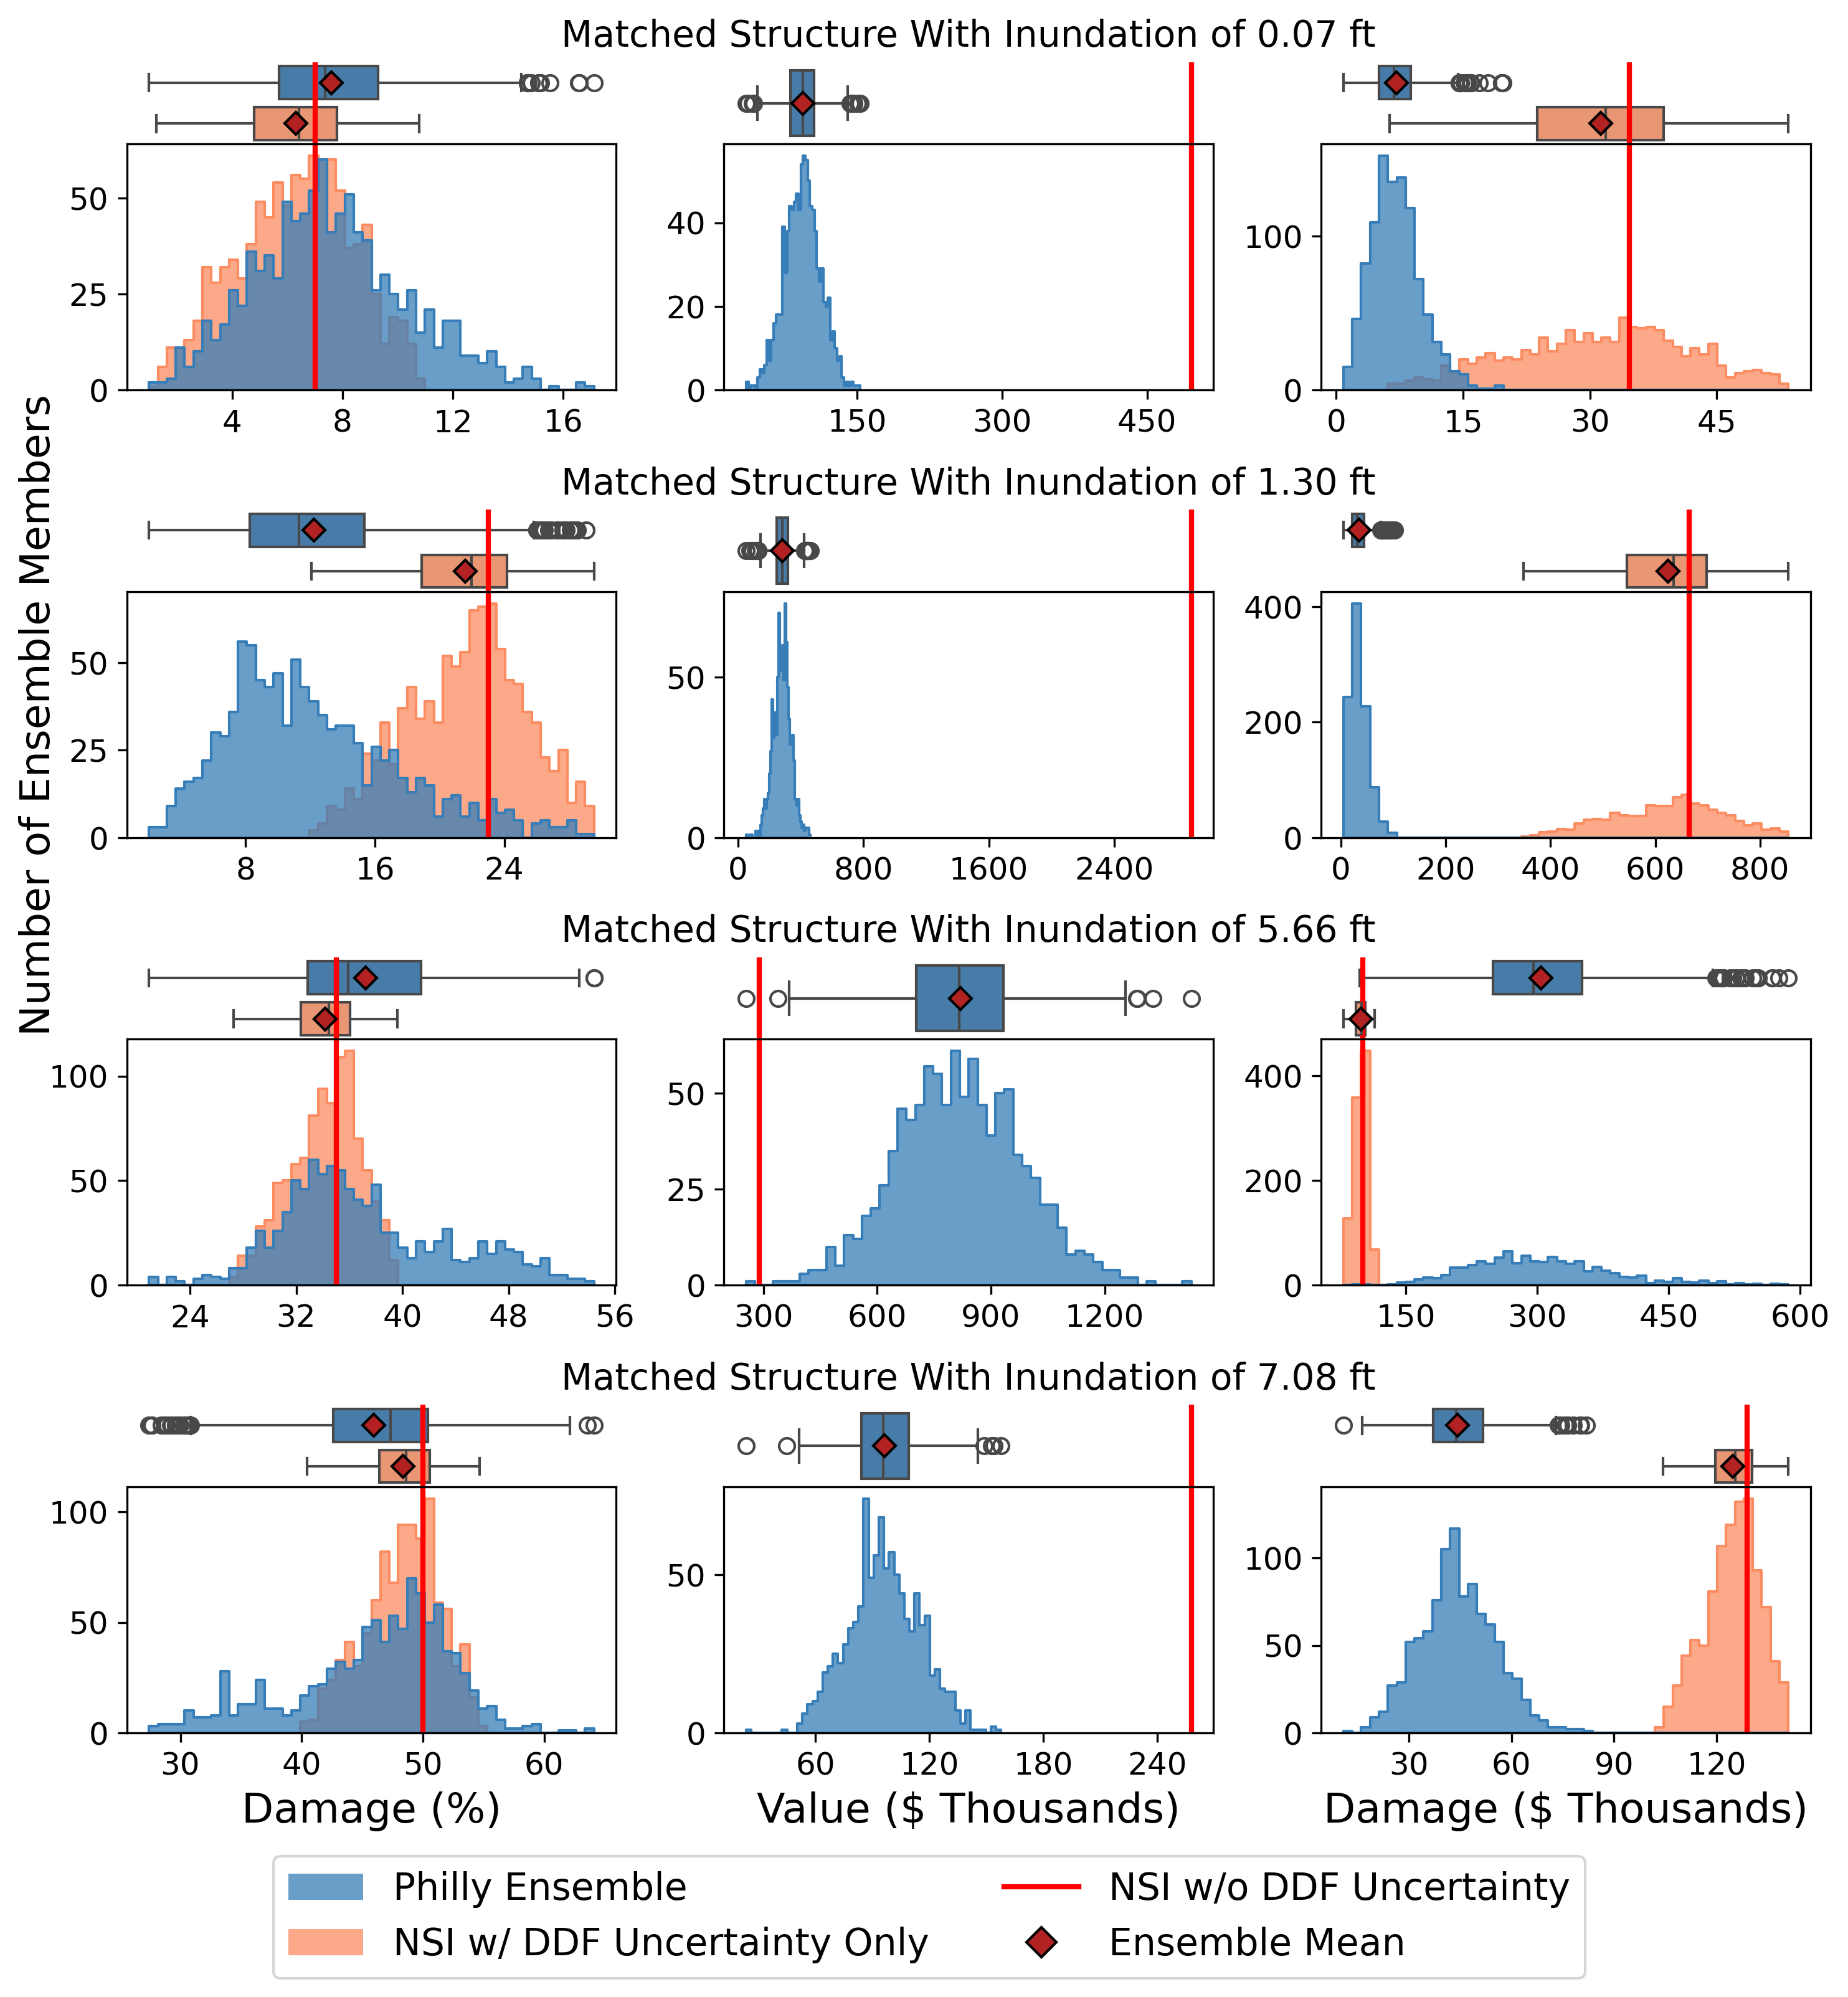

In [ ]:
def plot_building_damage_comparison(phil_data, nsi_data, ens_comp, bfids,
                                   depth_col='depth_ft',
                                   n_bins=50,
                                   dam_cols=['rel_loss', 'val_s', 'loss'],
                                   dam_labels=['Damage (%)', 'Value ($ Thousands)', 'Damage ($ Thousands)'],
                                   scale_factors=[1, 1e3, 1e3],
                                   phil_label='Philly Ensemble',
                                   ens_label='Alternate Ensemble'):
    """
    Create a generalized comparison of building damages between Philadelphia and NSI data.
    
    Parameters:
    -----------
    phil_data : DataFrame
        Philadelphia building data with damage columns
    nsi_data : DataFrame
        NSI building data with damage columns
    ens_comp : DataFrame
        Second ensemble data to compare with Philadelphia
    bfids : list
        List of building IDs to analyze
    depth_col : str
        Name of the column containing depth information
    n_bins: int
        Number of bins for histogram
    dam_cols : list
        List of damage column names to compare
    dam_labels : list
        Labels for the damage columns
    scale_factors : list
        Scaling factors for the damage values
    phil_label : str
        Label for the Philadelphia ensemble
    ens_label : str
        Label for the second ensemble
    """
    # Create figure with a grid layout
    fig = plt.figure(figsize=(10, 10), dpi=300)
    
    # Define colors for consistency
    philly_color = sns.color_palette('Set1')[1]
    ens_color = sns.color_palette('Set2')[1]
    nsi_color = 'red'
    
    # Process each building
    for i, bfid in enumerate(bfids):
        # Filter data for this building
        phil_plot = phil_data[phil_data['bfid'] == bfid]
        nsi_plot = nsi_data[nsi_data['bfid'] == bfid]
        ens_plot = ens_comp[ens_comp['bfid'] == bfid]
        
        # Get depth directly from the data
        depth = phil_plot[depth_col].iloc[0]  # Use Philadelphia data for depth
        
        # Process each damage column
        for j, (dam_col, dam_label, scale_factor) in enumerate(zip(dam_cols, dam_labels, scale_factors)):
            # Calculate subplot position
            subplot_idx = i * len(dam_cols) + j + 1
            
            # Create a subplot with 2 rows (boxplot on top, histogram below)
            ax = plt.subplot(len(bfids), len(dam_cols), subplot_idx)
            
            # Create a gridspec for this subplot to have boxplot on top and histogram below
            gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=ax.get_subplotspec(),
                                                 height_ratios=[1, 3], hspace=0)
            
            # Create the boxplot axes (top) and histogram axes (bottom)
            ax_box = fig.add_subplot(gs[0])
            ax_hist = fig.add_subplot(gs[1], sharex=ax_box)
            
            # Hide the main axes
            ax.axis('off')
            
            # Prepare data from both ensembles
            phil_values = (phil_plot.groupby(['sow_ind'])[[dam_col]].sum()/scale_factor).reset_index()[dam_col]
            ens_values = (ens_plot.groupby(['sow_ind'])[[dam_col]].sum()/scale_factor).reset_index()[dam_col]
            
            # Create combined DataFrame for seaborn
            if dam_col != 'val_s':
                combined_data = pd.DataFrame({
                    'value': pd.concat([phil_values, ens_values]),
                    'source': [phil_label] * len(phil_values) + [ens_label] * len(ens_values)
                })
            else:
                combined_data = pd.DataFrame({
                    'value': phil_values,
                    'source': [phil_label] * len(phil_values)
                })
            
            # Create histograms using seaborn
            sns.histplot(data=combined_data, x='value', hue='source', 
                        bins=n_bins, alpha=0.75, ax=ax_hist,
                        palette={phil_label: philly_color, ens_label: ens_color},
                        legend=False,
                        element="step", fill=True, stat="count")
            
            # Create boxplots using seaborn
            sns.boxplot(data=combined_data, x='value', y='source', 
                       orient='h', ax=ax_box,
                       hue='source',
                       legend=False,
                       palette={phil_label: philly_color, ens_label: ens_color},
                       showmeans=True,
                       meanprops={'markerfacecolor': 'firebrick',
                                 'markeredgecolor': 'black',
                                 'marker': 'D'})
            
            # Remove y-axis labels but keep the ticks for visual separation
            ax_box.set_yticklabels([])
            ax_box.set_yticks([])
            ax_box.set_xlabel('')
            ax_box.axis('off')  # Hide the boxplot axes
            
            # Add NSI reference line
            nsi_value = nsi_plot[dam_col].sum()/scale_factor
            ax_hist.axvline(nsi_value, color=nsi_color, linestyle='-', linewidth=2)
            ax_box.axvline(nsi_value, color=nsi_color, linestyle='-', linewidth=2)
            
            # Configure histogram
            ax_hist.grid(False)
            if i == len(bfids) - 1:  # Only add x-label to bottom row
                ax_hist.set_xlabel(dam_label, size=16)
            else:
                ax_hist.set_xlabel('')
            
            if j == 0 and i == 1:  # Only add y-label to first column of first row
                ax_hist.set_ylabel('Number of Ensemble Members', size=16)
            else:
                ax_hist.set_ylabel('')
            
            ax_hist.tick_params(labelsize=12)
            ax_hist.xaxis.set_major_locator(plt.MaxNLocator(5))
            
            # Process the x ticks for % damage
            if j == 0:
                ax_hist.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, symbol=None, decimals=0))
            
            # Remove the automatically generated legend
            if ax_hist.get_legend():
                ax_hist.get_legend().remove()

            # Add row title for depth
            # if j == 0:
                # ax.annotate(f"Matched Structure With Inundation of {depth:.2f} ft",
                #            xy=(1.1, 1.05),
                #            horizontalalignment='center',
                #            xycoords='axes fraction',
                #            fontsize=16)
            if j == 1:
                
                ax.set_title(f"Fully Matched Structure With Inundation of {depth:.2f} ft",
                             size=14)

    # Create legend elements
    legend_elements = [
        Patch(facecolor=philly_color, alpha=.75, label=phil_label),
        Patch(facecolor=ens_color, alpha=.75, label=ens_label),
        Line2D([0], [0], color=nsi_color, lw=2, label='NSI w/o DDF Uncertainty'),
        Line2D([0], [0], marker='D', markerfacecolor='firebrick',
              label='Ensemble Mean', ls='', markeredgecolor='black', markersize=8)
    ]
    
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(wspace=.22, hspace=None)
    
    # Add the legend
    plt.legend(handles=legend_elements,
              fontsize='x-large',
              loc='center',
              bbox_to_anchor=(-.8, -.75),
              frameon=True,
              ncol=2
    )
    
    return fig

# Find bfids from test_gb based on cases you'd like to illustrate
# I want to illustrate that at low depths, you can get large discrepancies
# because of large value disagreements
# I want to illustrate that at moderate depths, you can get small discrepancies
# on average but there is a lot of overlooked uncertainty in status quo and
# just depth-damage function uncertainty approaches
# I want to illustrate that at high depths, neglecting uncertainty in 
# first-floor elevation and structure value are highly consequential
# Even when everything seems to line up in a satisfying way for rel loss,
# when the rel loss values are relatively high, missing tails
# and misestimating value can be consequential
bfids = [48223, 94090 , 15611 , 25008]

nsi_bench = all_results['no_unc']
nsi_bench = nsi_inv_ens.join(nsi_bench).reset_index()
nsi_bench['rel_loss'] = nsi_bench[dam_col]/nsi_bench['val_struct']
nsi_bench['val_s'] = nsi_bench['val_struct'].copy()
nsi_bench['bfid'] = nsi_bench['fd_id'].map(fd_bfid_lnk)

fig = plot_building_damage_comparison(
    phil_data=main_phil, 
    ens_comp=nsi_ddf_unc,
    nsi_data=nsi_bench, 
    bfids=bfids,
    depth_col=dg_id,
    dam_cols=['rel_loss', 'val_s', dam_col],
    dam_labels= ['Damage (%)', 'Value ($ Thousands)', 'Damage ($ Thousands)'],
    scale_factors=[1, 1000, 1000],
    ens_label='NSI w/ DDF Uncertainty Only'
)

fig.savefig(join(FIG_DIR, 'fig3.png'), bbox_inches='tight', dpi=300)

### Figure 4
Damage discrepancies at census tract scale. Panel A shows mean damage of the Philadelphia ensemble for each census tract. Panel B shows the percent difference between the mean damage of the NSI ensemble accounting for DDF uncertainty only and the mean damage of the Philadelphia ensemble for each census tract. Panel C shows the rank ordering of census tracts according to both approaches and indicates regions for type 1 and type 2 errors for classifying the top 20th percentile of damage across census tracts. Points are filled with the same hue as Panel B to indicate tract-level discrepancy in percent. The gray line indicates consistent rank ordering across inventories. 

/Users/f006dwr/miniforge3/envs/nsi_fit/lib/python3.12/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)


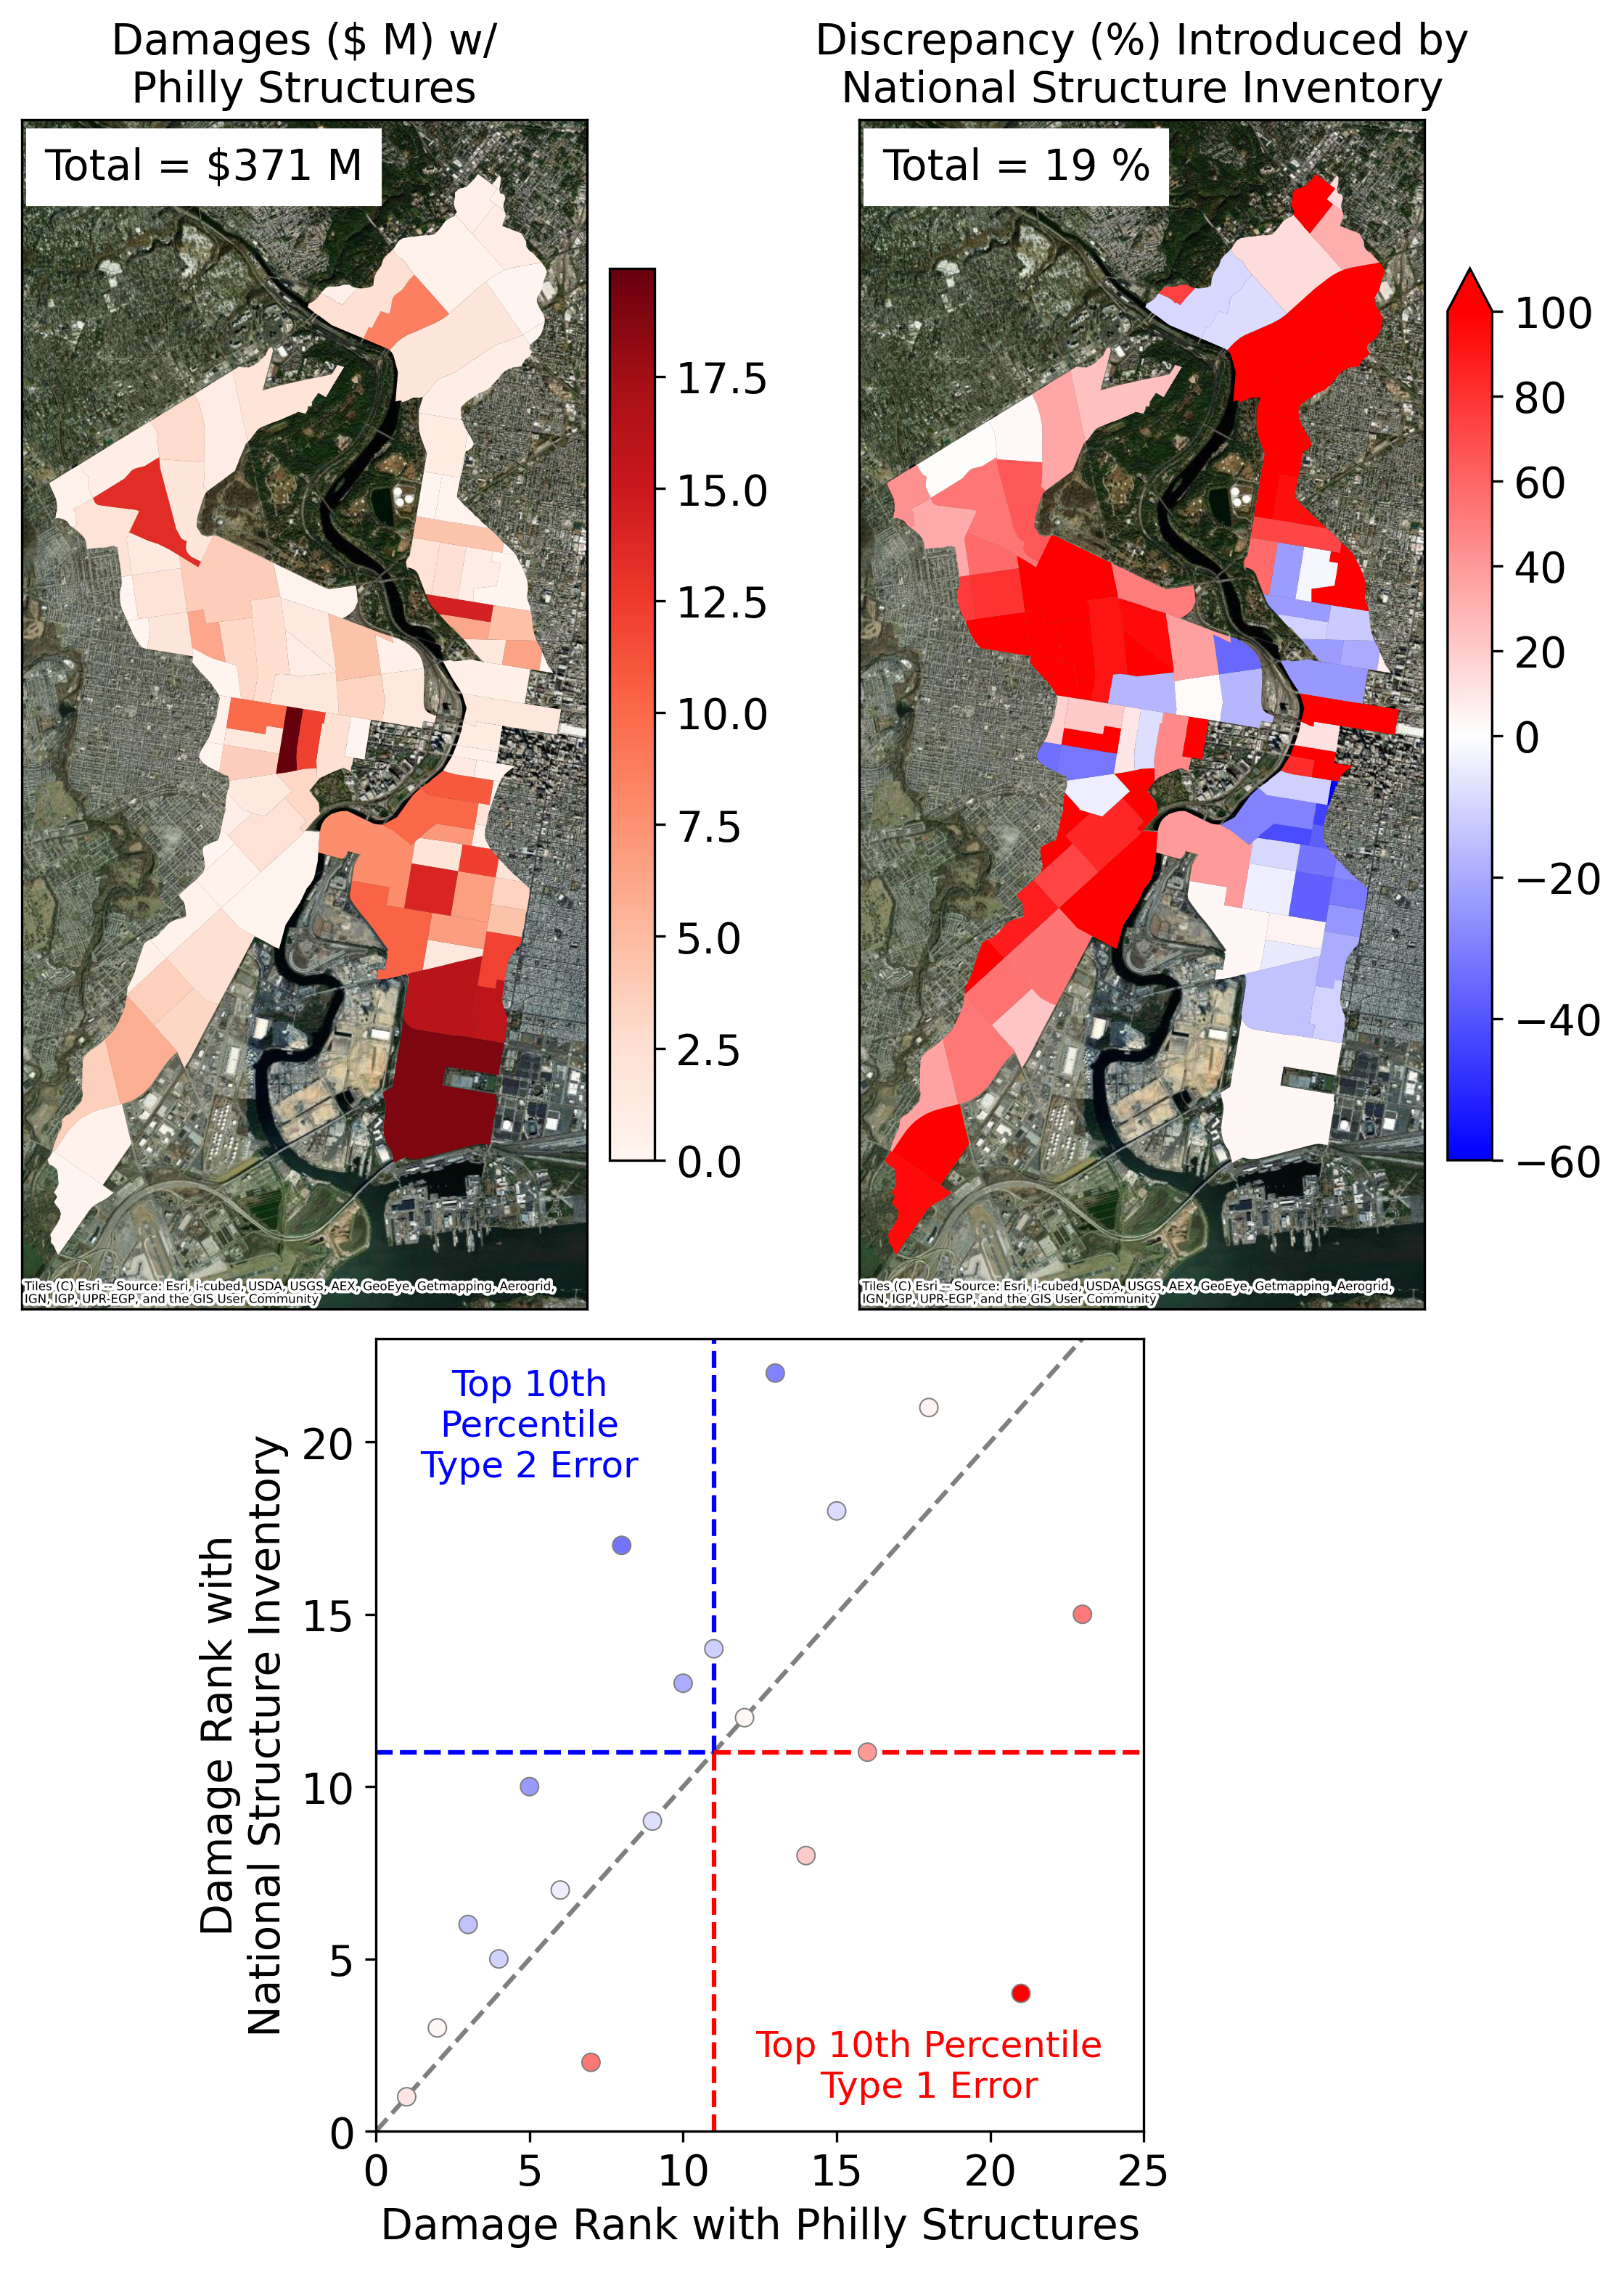

In [35]:
# Create figure
fig = plt.figure(figsize=(12, 12), dpi=300)

# Create two GridSpecs
# Top GridSpec for the maps
gs = gridspec.GridSpec(2, 5, height_ratios=[3, 2],
                       hspace=.03)

# Create axes for maps
ax0 = fig.add_subplot(gs[0, 0:2])
ax1 = fig.add_subplot(gs[0, 2:4])

# Create axes for scatterplot and boxplot
ax3 = fig.add_subplot(gs[1, 1:3])  # Scatterplot

comp_plot = comp_geo.to_crs(epsg=3857)

cmap = 'YlOrRd'

comp_plot['nsi_loss'] = comp_plot[dam_col + '_nsi_ddfs']/1e6
comp_plot['phil_loss'] = comp_plot[dam_col + '_phil']/1e6

comp_plot['dam_bias'] = comp_plot['nsi_loss'] - comp_plot['phil_loss']
comp_plot['rank_bias'] = (comp_plot['nsi_loss'].rank(ascending=False) -
                          comp_plot['phil_loss'].rank(ascending=False))

comp_plot['dam_pct_bias'] = 100*comp_plot['dam_bias']/comp_plot['phil_loss']+.01

total_nsi_loss = comp_plot['nsi_loss'].sum()
total_phil_loss = comp_plot['phil_loss'].sum()
total_pct_dev = np.round(100*(total_nsi_loss-total_phil_loss)/total_phil_loss)

vmin = min(comp_plot['nsi_loss'].min(), comp_plot['phil_loss'].min())
vmax = max(comp_plot['nsi_loss'].max(), comp_plot['phil_loss'].max())
vcenter=1

comp_plot[comp_plot['phil_loss'] > 0].plot(ax=ax0, column='phil_loss', cmap='Reds',
               legend=True,
               legend_kwds={'pad': .03,
                           'shrink': .75},
               vmin=0, vmax=comp_plot['phil_loss'].max())
comp_plot[comp_plot['phil_loss'] > 0].plot(ax=ax1, column='dam_pct_bias', cmap='bwr',
               legend=True,
               legend_kwds={'pad': .03,
                           'shrink': .75,
                           'extend': 'max'},
               norm=colors.TwoSlopeNorm(vmin=-60,
                                        vcenter=0,
                                        vmax=100))

cx.add_basemap(ax0,
               attribution_size=4,
               source=cx.providers.Esri.WorldImagery)

cx.add_basemap(ax1,
               attribution_size=4,
               source=cx.providers.Esri.WorldImagery)


axes = [ax0, ax1]
for i in range(len(axes)):
    axes[i].tick_params(
        axis="both",
        which="both",
        bottom=False,
        left=False,
        labelbottom=False,
        labelleft=False,
    )

# Add titles
axes[0].set_title("Damages ($ M) w/\nPhilly Structures", fontsize=14)
axes[1].set_title("Discrepancy (%) Introduced by\nNational Structure Inventory", fontsize=14)

# Add annotations
axes[0].annotate('Total = ${} M'.format(int(total_phil_loss)),
             xy=(.04, .95),
             xycoords='axes fraction',
             color='black',
             backgroundcolor='white',
             size=14
             )

axes[1].annotate('Total = {} %'.format(int(total_pct_dev)),
             xy=(.04, .95),
             xycoords='axes fraction',
             color='black',
             backgroundcolor='white',
             size=14
             )

# Update colorbar tick label size
for ax in fig.axes:
    if ax._axes.get_label() == '<colorbar>':
        ax.tick_params(labelsize='14')

comp_plot['val_thou'] = comp_plot['median_val_phil']/1e3
comp_plot['phil_rank'] = comp_plot['phil_loss'].rank(ascending=False)
comp_plot['nsi_rank'] = comp_plot['nsi_loss'].rank(ascending=False)

sns.scatterplot(
    ax=ax3,
    y='nsi_rank',
    x='phil_rank',
    edgecolor='gray',
    hue='dam_pct_bias',
    palette='bwr',
    hue_norm=colors.TwoSlopeNorm(vmin=-60,
                                        vcenter=0,
                                        vmax=100),
    data=comp_plot.sort_values('phil_rank', ascending=False),
    legend=False
)

ax3.axline([0, 0], [1, 1], color='black', linestyle='--', alpha=0.5, zorder=0)

ax3.set_xlabel('Damage Rank with Philly Structures', fontsize=14)
ax3.set_ylabel('Damage Rank with\nNational Structure Inventory', fontsize=14)
ax3.tick_params(labelsize=14)

ax3.annotate('Top 10th Percentile\nType 1 Error',
             (18, 1),
             xycoords='data',
             ha='center',
             color='red',
             size=12
             )

ax3.annotate('Top 10th\nPercentile\nType 2 Error',
             (5, 19),
             xycoords='data',
             ha='center',
             color='blue',
             size=12
             )

ax3.set_xlim([0, 25])
ax3.set_ylim([0, 23])

ax3.axvline(11, ymin=11/23., color='blue', linestyle='--', alpha=1, zorder=0)
ax3.axhline(11, xmax=11/25., color='blue', linestyle='--', alpha=1, zorder=0)
ax3.axvline(11, ymax=11/23., color='red', linestyle='--', alpha=1, zorder=0)
ax3.axhline(11, xmin=11/25., color='red', linestyle='--', alpha=1, zorder=0)

fig.savefig(join(FIG_DIR, 'fig4.png'), bbox_inches='tight', dpi=300)

In [38]:
len(comp_plot[comp_plot['dam_pct_bias'] >= 100])/len(comp_plot)

0.3130434782608696

In [41]:
len(comp_plot[comp_plot['dam_pct_bias'] <= 0])/len(comp_plot)

0.2956521739130435

In [46]:
len(comp_plot[(comp_plot['phil_rank'] <= 22) & (comp_plot['rank_bias'] == 0)])/len(comp_plot[comp_plot['phil_rank'] <= 22])

0.13636363636363635

In [47]:
len(comp_plot[(comp_plot['phil_rank'] <= 22) & (comp_plot['nsi_rank'] > 22)])/len(comp_plot[comp_plot['phil_rank'] <= 22])

0.18181818181818182

### Figure 5
Plot skill metrics. 

Performance metrics across six procedures with varying locations and treatment of uncertainty. “Status Quo NSI Use” (orange) is based on NSI locations and structure characteristics with no uncertainty in any structure characteristic or depth-damage functions. “NSI w/ All Uncertainty” (red) is based on NSI locations, accounts for uncertainty in first-floor elevation and depth-damage functions, and samples all structure characteristics from proportions of NSI characteristic types at the census tract level. Other procedures follow analogous definitions. Each metric is relative to the ensemble mean of the corresponding estimate from the Philadelphia inventory with uncertainty in structure value, first-floor elevation, and depth-damage functions. Panel A and B show total damage discrepancy of the procedures in million dollars and percentage, respectively. Panel C shows the root mean square error of damage discrepancy across census tracts. Panel D shows the standard error of damage rank discrepancies at the tract level. Panel E shows the percentage of census tracts misclassified with respect to the top 10th percentile of most damaged tracts. Panel F shows the percentage of census tracts with the correct ranking inside the top 10th percentile of most damaged tracts. 


In [12]:
def plot_skill_metrics_box(metrics_data, exps, titles, colors, figsize=(12, 8)):
    """
    Create a 2×2 plot of skill metrics using seaborn boxplots with direction indicators.
    
    Parameters:
    -----------
    metrics_data : dict
        Dictionary with experiment names as keys and pandas DataFrames of metrics as values.
    exps : list
        List of experiment names to include
    titles : list
        List of display titles for each experiment
    colors : list
        List of colors for each experiment
    figsize : tuple
        Figure size
    """
    # Define the metrics to plot and their labels, along with preferred direction
    # (True = higher is better, False = lower is better)
    metrics_to_plot = [
        ('total_discrepancy_dollar', 'Total Discrepancy ($ Millions)', False),
        ('total_discrepancy_pct', 'Total Discrepancy (%)', False),
        ('type1_pct', 'Misclassified as Top 10% Damaged Tracts', False),
        ('matched_top_rank_pct', 'Correct Top 10% Damaged Rank', True),
    ]
    
    # Set up the figure with a 2×2 grid
    fig, axes = plt.subplots(2, 2, figsize=figsize, dpi=300,
                            gridspec_kw={'wspace': 0.2, 'hspace': 0.25})
    axes = axes.flatten()
    
    # Create a color palette dictionary for consistent coloring
    palette_dict = dict(zip(exps, colors))
    
    # Define which boxplots to emphasize
    primary_index = 0    # Most common way people use NSI (leftmost)
    secondary_index = 1  # Main comparison evaluated (second from left)

    # Create each subplot
    for i, (metric_key, metric_label, higher_is_better) in enumerate(metrics_to_plot):
        ax = axes[i]
        
        # Filter data for this metric
        metric_data = metrics_data[metrics_data['metric'] == metric_key]
        
        # Determine the optimal value
        if metric_key in ['total_discrepancy_dollar', 'total_discrepancy_pct']:
            # For discrepancy metrics, 0 is the optimal value
            optimal_value = 0
        elif higher_is_better:
            # For other metrics where higher is better
            optimal_value = metric_data['value'].max()
        else:
            # For other metrics where lower is better
            optimal_value = metric_data['value'].min()
        
        # Add a horizontal line at the optimal value (behind the boxplots)
        ax.axhline(y=optimal_value, color='green', linestyle='--', 
                  alpha=0.7, linewidth=1.5, zorder=1)
        
        # Add background highlights for important boxplots
        y_min, y_max = metric_data['value'].min(), metric_data['value'].max()
        padding = 0.1 * (y_max - y_min)
        y_min -= padding
        y_max += padding
        
        # Add background highlight for primary boxplot
        # ax.axvspan(primary_index - 0.4, primary_index + 0.4, 
        #           color='lightgray', alpha=0.3, zorder=0)
        
        # Add background highlight for secondary boxplot
        ax.axvspan(secondary_index - 0.4, secondary_index + 0.4, 
                  color='lightgray', alpha=0.3, zorder=0)
        
        # Add optimal value line
        ax.axhline(y=optimal_value, color='green', linestyle='--', 
                  alpha=0.7, linewidth=1.5, zorder=1)

        # Create seaborn boxplot (with higher zorder to appear in front)
        sns.boxplot(
            x='experiment',
            y='value',
            data=metric_data,
            palette=palette_dict,
            width=0.7,
            showfliers=True, 
            ax=ax,
            zorder=2  # Ensure boxplots are drawn on top of the line
        )
        
        # Set title only - no axis labels
        ax.set_title(metric_label, fontsize=14, pad=15)
        ax.set_xlabel('')  # Remove x-label
        ax.set_ylabel('')  # Remove y-label

        ax.tick_params(labelsize=12)
        
        # Format y-axis for percentage metrics
        if 'pct' in metric_key:
            ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.0f}%'))
        
        # Add grid
        ax.grid(axis='y', linestyle='--', alpha=0.3, linewidth=0.5)
        
        # Remove top and right spines
        sns.despine(ax=ax)
        
        # Remove x-tick labels and ticks
        ax.set_xticklabels([])
        ax.set_xticks([])
    
    # Create legend elements
    legend_elements = []
    
    # Add experiment colors to legend
    for i, title in enumerate(titles):
        legend_elements.append(Patch(facecolor=colors[i], label=title))
    
    # Add optimal value line to legend
    legend_elements.append(Line2D([0], [0], color='green', linestyle='--',
                                 label='Target Value', alpha=0.7, linewidth=1.5))
    
    # Add the legend at the bottom of the figure
    l = fig.legend(handles=legend_elements,
              loc='lower center',
              frameon=True,
              fancybox=False,
              fontsize=12,
              labelspacing=.75,
              ncol=2,  # Two columns for better layout
              bbox_to_anchor=(0.5, -0.05),  # Position below the plots
              edgecolor='black')
    
    for i, text in enumerate(l.get_texts()):
        if i == secondary_index:
            text.set_backgroundcolor("#d3d3d34d")

    # Adjust bottom margin to make room for the legend
    fig.tight_layout()
    fig.subplots_adjust(bottom=0.15)
    
    return fig, axes

/var/folders/d2/g0h08s551zb2hz_ws2g4ggh400hbd0/T/ipykernel_29391/1852883149.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/d2/g0h08s551zb2hz_ws2g4ggh400hbd0/T/ipykernel_29391/1852883149.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/d2/g0h08s551zb2hz_ws2g4ggh400hbd0/T/ipykernel_29391/1852883149.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/d2/g0h08s551zb2hz_ws2g4ggh400hbd0/T/ipykernel_29391/1852883149.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

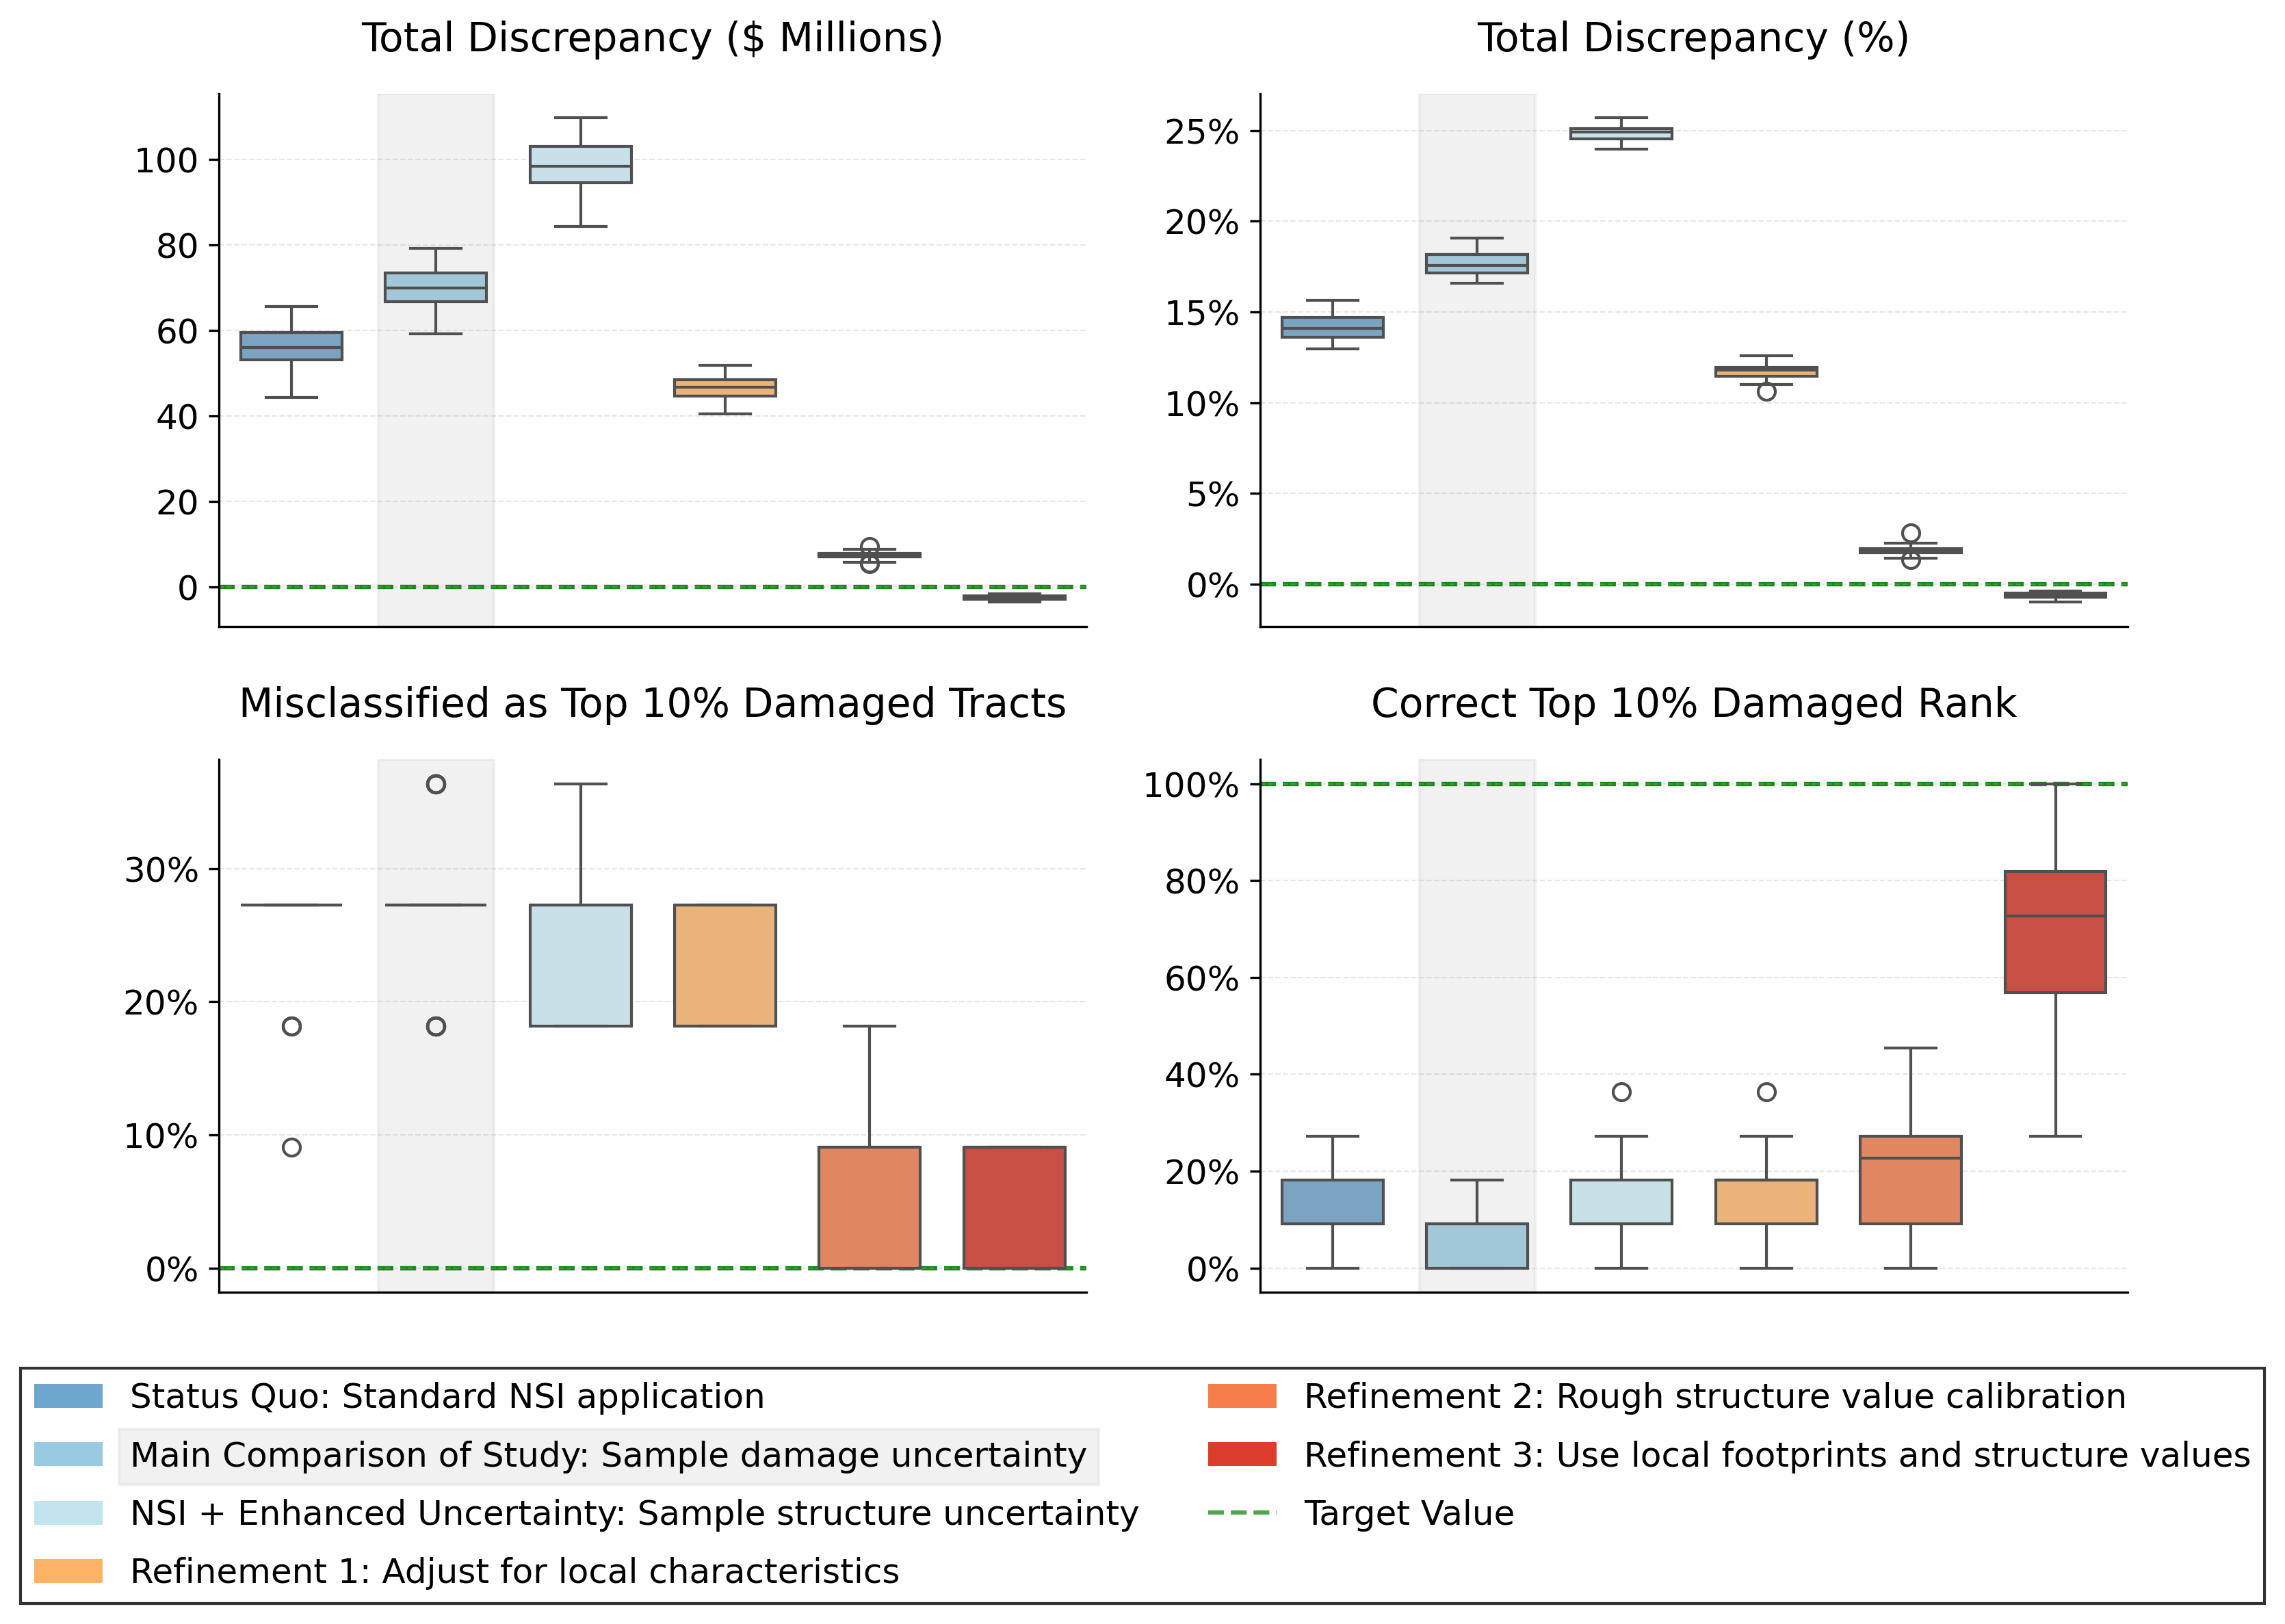

In [13]:
exps = ['nsi_nounc', 'nsi_ddfs', 'nsi_unsafe', 'nsi_phil', 'nsi_allphil', 'phil_unsafe']
titles = ['Status Quo: Standard NSI application',
          'Main Comparison of Study: Sample damage uncertainty',
          'NSI + Enhanced Uncertainty: Sample structure uncertainty',
          'Refinement 1: Adjust for local characteristics',
          'Refinement 2: Rough structure value calibration',
          'Refinement 3: Use local footprints and structure values']

# Define distinct colors for each method
hues = ['#6EA6CD', '#98CAE1', '#C2E4EF', '#FDB366', '#F67E4B', '#DD3D2D']

# Create the plot
metric_ens = pd.read_parquet(join(FO, 'ensembles', 'all_metrics_sa3.pqt'))
fig, axes = plot_skill_metrics_box(metric_ens, exps, titles, hues)
fig.savefig(join(FIG_DIR, 'fig5.png'), bbox_inches='tight', dpi=300)

In [11]:
len(metric_ens[(metric_ens['experiment'] == 'nsi_ddfs')
           & (metric_ens['metric'] == 'matched_top_rank_pct')
           & (metric_ens['value'] == 0)])

16

In [64]:
len(metric_ens[(metric_ens['experiment'] == 'nsi_ddfs')
           & (metric_ens['metric'] == 'matched_top_rank_pct')
           & (metric_ens['value'] < 18)])

38

In [74]:
len(metric_ens[(metric_ens['experiment'] == 'phil_unsafe')
           & (metric_ens['metric'] == 'matched_top_rank_pct')
           & (metric_ens['value'] > 90)])

8

In [79]:
len(metric_ens[(metric_ens['experiment'] == 'phil_unsafe')
           & (metric_ens['metric'] == 'matched_top_rank_pct')
           & (metric_ens['value'] == 100)])

5